# Steven A. Bonilla


# 1. Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from matplotlib.ticker import StrMethodFormatter
import matplotlib.dates as mdates
import seaborn as sns
from functools import reduce

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit

import matplotlib.dates as mdates


# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


# 2. Datasets

In [2]:
# Load datasets
import pandas as pd

egg = pd.read_csv("data/egg_prices.csv")
corn = pd.read_csv("data/corn_prices.csv")
soybean = pd.read_csv("data/soybean_prices.csv")
diesel = pd.read_csv("data/diesel_prices.csv")
cpi = pd.read_csv("data/cpi.csv")

bird_flu = pd.read_csv(
    "data/bird_flu.csv",
    encoding="utf-16",
    sep=None,
    engine="python"
)

print("All datasets loaded successfully!")

All datasets loaded successfully!


# 3. Print Columns

In [3]:
# Display the columns of each dataset to verify the structure
print(egg.columns)
print(corn.columns)
print(soybean.columns)
print(diesel.columns)
print(cpi.columns)
print(bird_flu.columns)


Index(['observation_date', 'APU0000708111'], dtype='str')
Index(['observation_date', 'PMAIZMTUSDM'], dtype='str')
Index(['observation_date', 'PSOYBUSDM'], dtype='str')
Index(['observation_date', 'APU000074717'], dtype='str')
Index(['observation_date', 'CPIAUCSL'], dtype='str')
Index(['Special ID', 'County Name', 'State', 'Production',
       'Confirmed Diagnosis', 'Control Area Released', 'Unnamed: 6'],
      dtype='str')


# 4. Rename columns 

In [4]:
# Rename Egg dataset columns for clarity
egg = egg.rename(columns={
    "observation_date": "date",
    "APU0000708111": "egg_price"
})

egg["date"] = pd.to_datetime(egg["date"])

print(egg.columns)
display(egg.head())



Index(['date', 'egg_price'], dtype='str')


,date,egg_price
0,1980-01-01,0.879
1,1980-02-01,0.774
2,1980-03-01,0.812
3,1980-04-01,0.797
4,1980-05-01,0.737


In [5]:
# Rename Corn dataset columns for clarity
corn = corn.rename(columns={
    "observation_date": "date",
    "PMAIZMTUSDM": "corn_price"
})

corn["date"] = pd.to_datetime(corn["date"])

print(corn.columns)
display(corn.head())

Index(['date', 'corn_price'], dtype='str')


,date,corn_price
0,1992-01-01,109.586357
1,1992-02-01,113.921257
2,1992-03-01,116.684593
3,1992-04-01,109.055138
4,1992-05-01,109.177910


In [6]:
# Rename Soybean dataset columns for clarity
soybean = soybean.rename(columns={
    "observation_date": "date",
    "PSOYBUSDM": "soybean_price"
})

soybean["date"] = pd.to_datetime(soybean["date"])

print(soybean.columns)
display(soybean.head())

Index(['date', 'soybean_price'], dtype='str')


,date,soybean_price
0,1992-01-01,208.610226
1,1992-02-01,211.159575
2,1992-03-01,216.143437
3,1992-04-01,211.297378
4,1992-05-01,220.369384


In [7]:
# Rename Diesel dataset columns for clarity
diesel = diesel.rename(columns={
    "observation_date": "date",
    "APU000074717": "diesel_price"
})

diesel["date"] = pd.to_datetime(diesel["date"])

print(diesel.columns)
display(diesel.head())


Index(['date', 'diesel_price'], dtype='str')


,date,diesel_price
0,1998-01-01,1.250
1,1998-02-01,1.220
2,1998-03-01,1.192
3,1998-04-01,1.184
4,1998-05-01,1.190


In [8]:
# Rename CPI dataset columns for clarity
cpi = cpi.rename(columns={
    "observation_date": "date",
    "CPIAUCSL": "cpi"
})

cpi["date"] = pd.to_datetime(cpi["date"])

print(cpi.columns)
display(cpi.head())

Index(['date', 'cpi'], dtype='str')


,date,cpi
0,1947-01-01,21.48
1,1947-02-01,21.62
2,1947-03-01,22.00
3,1947-04-01,22.00
4,1947-05-01,21.95


In [9]:
# Rename columns
# Rename columns
bird_flu = bird_flu.rename(columns={
    "Confirmed Diagnosis": "date",
    "Unnamed: 6": "bird_affected"
})

# Keep only important columns
bird_flu = bird_flu[["date", "bird_affected"]].copy()

# Convert date
bird_flu["date"] = pd.to_datetime(
    bird_flu["date"],
    format="%d-%b-%y",
    errors="coerce"
)

# Convert birds affected to numbers
bird_flu["bird_affected"] = pd.to_numeric(
    bird_flu["bird_affected"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip(),
    errors="coerce"
)

# Remove invalid rows
bird_flu = bird_flu.dropna(
    subset=["date", "bird_affected"]
)

bird_flu["bird_affected"] = bird_flu["bird_affected"].astype(int)
display(bird_flu.head())

,date,bird_affected
0,2026-07-13,275100
1,2026-07-06,1216000
2,2026-06-23,3000
3,2026-06-18,20
4,2026-06-12,450


In [10]:
# Convert daily outbreak dates to monthly dates
bird_flu["date"] = (
    bird_flu["date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Add all birds affected during the same month
bird_flu_monthly = (
    bird_flu.groupby("date", as_index=False)["bird_affected"]
            .sum()
)

print("Monthly bird flu data:")
display(bird_flu_monthly.head())

print("Largest monthly totals:")
display(
    bird_flu_monthly.nlargest(10, "bird_affected")
)

Monthly bird flu data:


,date,bird_affected
0,2022-02-01,1487328
1,2022-03-01,20958587
2,2022-04-01,14686259
3,2022-05-01,783375
4,2022-06-01,2173327


Largest monthly totals:


,date,bird_affected
34,2025-01-01,23189254
1,2022-03-01,20958587
33,2024-12-01,18249765
2,2022-04-01,14686259
35,2025-02-01,12640188
21,2023-12-01,11431926
47,2026-02-01,11405160
25,2024-04-01,8807250
20,2023-11-01,8081779
32,2024-11-01,6932565


# 5. Inspect Each Dataset

In [11]:
# Egg Inspection

# First 5 row
print("Egg first 5 rows:")
print(egg.head())
print("\n")

# Dataset information
print("Dataset information:")
egg.info()
print("\n")

# Summary statistics
print("Summary statistics:")
print(egg.describe())
print("\n")

# Number of row and columns
print("Number of rows and columns:")
print(egg.shape)
print("\n")

# Column names
print("Column names:")
print(egg.columns)
print("\n")

# Check for missing values
print("Missing values:")
print(egg.isnull().sum())

egg[egg.isnull().any(axis=1)]

Egg first 5 rows:
        date  egg_price
0 1980-01-01      0.879
1 1980-02-01      0.774
2 1980-03-01      0.812
3 1980-04-01      0.797
4 1980-05-01      0.737


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 558 entries, 0 to 557
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       558 non-null    datetime64[us]
 1   egg_price  557 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 8.8 KB


Summary statistics:
                             date   egg_price
count                         558  557.000000
mean   2003-03-17 12:41:17.419354    1.439266
min           1980-01-01 00:00:00    0.678000
25%           1991-08-08 18:00:00    0.916000
50%           2003-03-16 12:00:00    1.165000
75%           2014-10-24 06:00:00    1.771000
max           2026-06-01 00:00:00    6.227000
std                           NaN    0.758421


Number of rows and columns:
(558, 2)


,date,egg_price
549,2025-10-01,NaN


In [12]:
# Corn Inspection
# First 5 row
print("corn first 5 rows:")
print(corn.head())
print("\n")

# Dataset information
print("Dataset information:")
corn.info()
print("\n")

# Summary statistics
print("Summary statistics:")
print(corn.describe())
print("\n")

# Number of row and columns
print("Number of rows and columns:")
print(corn.shape)
print("\n")

# Column names
print("Column names:")
print(corn.columns)
print("\n")

# Check for missing values
print("Missing values:")
print(corn.isnull().sum())

corn[corn.isnull().any(axis=1)]

corn first 5 rows:
        date  corn_price
0 1992-01-01  109.586357
1 1992-02-01  113.921257
2 1992-03-01  116.684593
3 1992-04-01  109.055138
4 1992-05-01  109.177910


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        414 non-null    datetime64[us]
 1   corn_price  414 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 6.6 KB


Summary statistics:
                             date  corn_price
count                         414  414.000000
mean   2009-03-17 00:45:13.043478  165.721475
min           1992-01-01 00:00:00   75.057375
25%           2000-08-08 18:00:00  106.908205
50%           2009-03-16 12:00:00  159.864476
75%           2017-10-24 06:00:00  200.560707
max           2026-06-01 00:00:00  348.507117
std                           NaN   67.180646


Number of rows and columns

,date,corn_price


In [13]:
# Soybean Inspection
# First 5 row
print("Soybean first 5 rows:")
print(soybean.head())
print("\n")

# Dataset information
print("Dataset information:")
soybean.info()
print("\n")

# Summary statistics
print("Summary statistics:")
print(soybean.describe())
print("\n")

# Number of row and columns
print("Number of rows and columns:")
print(soybean.shape)
print("\n")

# Column names
print("Column names:")
print(soybean.columns)
print("\n")

# Check for missing values
print("Missing values:")
print(soybean.isnull().sum())

soybean[soybean.isnull().any(axis=1)]

Soybean first 5 rows:
        date  soybean_price
0 1992-01-01     208.610226
1 1992-02-01     211.159575
2 1992-03-01     216.143437
3 1992-04-01     211.297378
4 1992-05-01     220.369384


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           414 non-null    datetime64[us]
 1   soybean_price  414 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 6.6 KB


Summary statistics:
                             date  soybean_price
count                         414     414.000000
mean   2009-03-17 00:45:13.043478     334.760983
min           1992-01-01 00:00:00     158.312263
25%           2000-08-08 18:00:00     219.284189
50%           2009-03-16 12:00:00     326.775085
75%           2017-10-24 06:00:00     422.073525
max           2026-06-01 00:00:00     622.913550
std              

,date,soybean_price


In [14]:
# Diesel Inspection
# First 5 row
print("Diesel first 5 rows:")
print(diesel.head())
print("\n")

# Dataset information
print("Dataset information:")
diesel.info()
print("\n")

# Summary statistics
print("Summary statistics:")
print(diesel.describe())
print("\n")

# Number of row and columns
print("Number of rows and columns:")
print(diesel.shape)
print("\n")

# Column names
print("Column names:")
print(diesel.columns)
print("\n")

# Check for missing values
print("Missing values:")
print(diesel.isnull().sum())

diesel[diesel.isnull().any(axis=1)]

Diesel first 5 rows:
        date  diesel_price
0 1998-01-01         1.250
1 1998-02-01         1.220
2 1998-03-01         1.192
3 1998-04-01         1.184
4 1998-05-01         1.190


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          342 non-null    datetime64[us]
 1   diesel_price  341 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 5.5 KB


Summary statistics:
                             date  diesel_price
count                         342    341.000000
mean   2012-03-16 18:27:22.105263      2.906762
min           1998-01-01 00:00:00      1.094000
25%           2005-02-08 00:00:00      2.129000
50%           2012-03-16 12:00:00      2.933000
75%           2019-04-23 12:00:00      3.773000
max           2026-06-01 00:00:00      5.780000
std                           NaN   

,date,diesel_price
333,2025-10-01,NaN


In [15]:
# CPI Inspection
# First 5 row
print("CPI first 5 rows:")
print(cpi.head())
print("\n")

# Dataset information
print("Dataset information:")
cpi.info()
print("\n")

# Summary statistics
print("Summary statistics:")
print(cpi.describe())
print("\n")

# Number of row and columns
print("Number of rows and columns:")
print(cpi.shape)
print("\n")

# Column names
print("Column names:")
print(cpi.columns)
print("\n")

# Check for missing values
print("Missing values:")
print(cpi.isnull().sum())

cpi[cpi.isnull().any(axis=1)]

CPI first 5 rows:
        date    cpi
0 1947-01-01  21.48
1 1947-02-01  21.62
2 1947-03-01  22.00
3 1947-04-01  22.00
4 1947-05-01  21.95


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 954 entries, 0 to 953
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    954 non-null    datetime64[us]
 1   cpi     953 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 15.0 KB


Summary statistics:
                             date         cpi
count                         954  953.000000
mean   1986-09-15 21:30:33.962264  125.149592
min           1947-01-01 00:00:00   21.480000
25%           1966-11-08 12:00:00   32.880000
50%           1986-09-16 00:00:00  110.000000
75%           2006-07-24 06:00:00  201.900000
max           2026-06-01 00:00:00  333.979000
std                           NaN   90.424428


Number of rows and columns:
(954, 2)


Column names:
Index(['date', 'cpi

,date,cpi
945,2025-10-01,NaN


In [16]:
# Bird Flu  Inspection
# First 5 row
print("Bird Flu first 5 rows:")
print(bird_flu.head())
print("\n")

# Dataset information
print("Dataset information:")
bird_flu.info()
print("\n")

# Summary statistics
print("Summary statistics:")
print(bird_flu.describe())
print("\n")

# Number of row and columns
print("Number of rows and columns:")
print(bird_flu.shape)
print("\n")

# Column names
print("Column names:")
print(bird_flu.columns)
print("\n")

# Check for missing values
print("Missing values:")
print(bird_flu.isnull().sum())

bird_flu[bird_flu.isnull().any(axis=1)]

Bird Flu first 5 rows:
        date  bird_affected
0 2026-07-01         275100
1 2026-07-01        1216000
2 2026-06-01           3000
3 2026-06-01             20
4 2026-06-01            450


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 2236 entries, 0 to 2235
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2236 non-null   datetime64[us]
 1   bird_affected  2236 non-null   int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 35.1 KB


Summary statistics:
                             date  bird_affected
count                        2236   2.236000e+03
mean   2024-03-02 13:43:02.468694   9.310184e+04
min           2022-02-01 00:00:00   0.000000e+00
25%           2022-10-01 00:00:00   5.000000e+01
50%           2024-04-01 00:00:00   3.000000e+03
75%           2025-04-01 00:00:00   3.400000e+04
max           2026-07-01 00:00:00   5.347500e+06
std            

,date,bird_affected


# 6. Handle Missing Values

In [17]:
egg = egg.interpolate(
    method="linear",
    limit_direction="forward",
    axis=0
)

diesel = diesel.interpolate(
    method="linear",
    limit_direction="forward",
    axis=0
)

soybean = soybean.interpolate(
    method="linear",
    limit_direction="forward",
    axis=0
)

corn = corn.interpolate(
    method="linear",
    limit_direction="forward",
    axis=0
)

cpi = cpi.interpolate(
    method="linear",
    limit_direction="forward",
    axis=0
)

In [18]:
print(egg.isnull().sum())
print(diesel.isnull().sum())
print(soybean.isnull().sum())
print(cpi.isnull().sum())
print(bird_flu.isnull().sum())

date         0
egg_price    0
dtype: int64
date            0
diesel_price    0
dtype: int64
date             0
soybean_price    0
dtype: int64
date    0
cpi     0
dtype: int64
date             0
bird_affected    0
dtype: int64


# 7. Merge Datasets

In [19]:
# Convert bird_affected to numeric

bird_flu_monthly["bird_affected"] = (
    bird_flu_monthly["bird_affected"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

bird_flu_monthly["bird_affected"] = pd.to_numeric(
    bird_flu_monthly["bird_affected"],
    errors="coerce"
)

bird_flu_monthly["bird_affected"] = (
    bird_flu_monthly["bird_affected"].fillna(0)
)

print(bird_flu_monthly.dtypes)

date             datetime64[us]
bird_affected             int64
dtype: object


In [20]:
bird_flu_monthly = (
    bird_flu_monthly
    .groupby("date", as_index=False)
    .agg({
        "bird_affected": "sum"
    })
)

In [21]:
datasets = [egg, corn, soybean, diesel, cpi]

for data in datasets:
    data["date"] = pd.to_datetime(data["date"])
    data["date"] = (
        data["date"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )

bird_flu_monthly["date"] = pd.to_datetime(
    bird_flu_monthly["date"]
)

bird_flu_monthly["date"] = (
    bird_flu_monthly["date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

In [22]:
egg_monthly = (
    egg.groupby("date", as_index=False)
       .agg({"egg_price": "mean"})
)

corn_monthly = (
    corn.groupby("date", as_index=False)
        .agg({"corn_price": "mean"})
)

soybean_monthly = (
    soybean.groupby("date", as_index=False)
            .agg({"soybean_price": "mean"})
)

diesel_monthly = (
    diesel.groupby("date", as_index=False)
           .agg({"diesel_price": "mean"})
)

cpi_monthly = (
    cpi.groupby("date", as_index=False)
       .agg({"cpi": "mean"})
)

In [23]:
df = egg_monthly.merge(corn_monthly, on="date", how="inner")

df = df.merge(
    soybean_monthly,
    on="date",
    how="inner"
)

df = df.merge(
    diesel_monthly,
    on="date",
    how="inner"
)

df = df.merge(
    cpi_monthly,
    on="date",
    how="inner"
)

df = df.merge(
    bird_flu_monthly,
    on="date",
    how="left"
)

df["bird_affected"] = (
    df["bird_affected"]
    .fillna(0)
)

df = (
    df.sort_values("date")
      .reset_index(drop=True)
)

print(df.columns)
print(df.head())
print(df.shape)

Index(['date', 'egg_price', 'corn_price', 'soybean_price', 'diesel_price',
       'cpi', 'bird_affected'],
      dtype='str')
        date  egg_price  corn_price  soybean_price  diesel_price    cpi  \
0 1998-01-01      1.120  114.367256     246.000675         1.250  162.0   
1 1998-02-01      1.073  113.618736     247.424636         1.220  162.0   
2 1998-03-01      1.043  113.840439     240.121096         1.192  162.0   
3 1998-04-01      1.061  106.687859     235.091300         1.184  162.2   
4 1998-05-01      0.960  105.966927     236.147786         1.190  162.6   

   bird_affected  
0            0.0  
1            0.0  
2            0.0  
3            0.0  
4            0.0  
(342, 7)


In [24]:
print("Duplicate dates:", df["date"].duplicated().sum())

print(df.isnull().sum())

Duplicate dates: 0
date             0
egg_price        0
corn_price       0
soybean_price    0
diesel_price     0
cpi              0
bird_affected    0
dtype: int64


# 8. Exploratory Data Analysis (EDA)

## Univariate Analysis 


### Egg

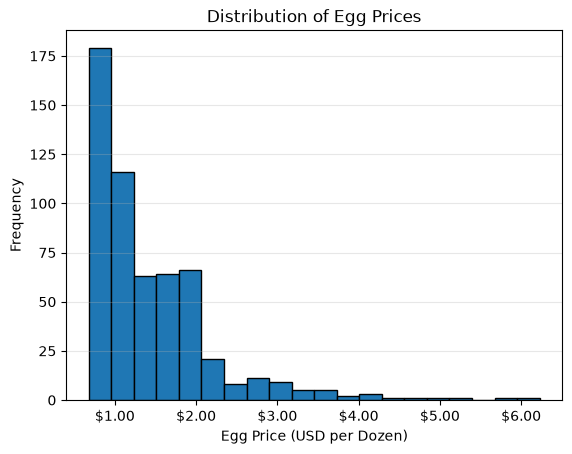

In [25]:
plt.hist(
    egg["egg_price"],
    bins=20,
    edgecolor='black'
)

plt.title("Distribution of Egg Prices")
plt.xlabel("Egg Price (USD per Dozen)")
plt.ylabel("Frequency")

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('${x:,.2f}'))

plt.grid(axis='y', alpha=0.3)

plt.show()

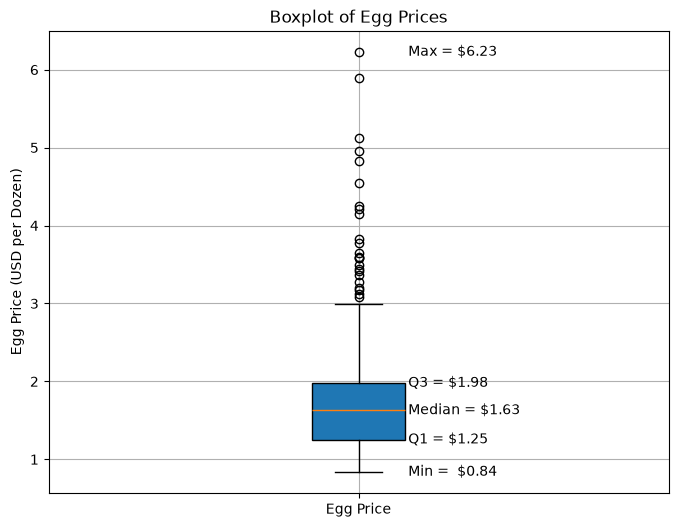

In [26]:
# Calculate quartiles
Q1 = df["egg_price"].quantile(0.25)
Median = df["egg_price"].median()
Q3 = df["egg_price"].quantile(0.75)
Minimum = df["egg_price"].min()
Maximum = df["egg_price"].max()

plt.figure(figsize=(8,6))

# Create boxplot
plt.boxplot(df["egg_price"], patch_artist=True)

# Title and labels
plt.title("Boxplot of Egg Prices")
plt.ylabel("Egg Price (USD per Dozen)")
plt.xticks([1], ["Egg Price"])

# Annotate the statistics
plt.text(1.08, Minimum, f"Min =  ${Minimum:.2f}", va='center')
plt.text(1.08, Q1, f"Q1 = ${Q1:.2f}", va='center')
plt.text(1.08, Median, f"Median = ${Median:.2f}", va='center')
plt.text(1.08, Q3, f"Q3 = ${Q3:.2f}", va='center')
plt.text(1.08, Maximum, f"Max = ${Maximum:.2f}", va='center')

plt.grid(True)
plt.show()

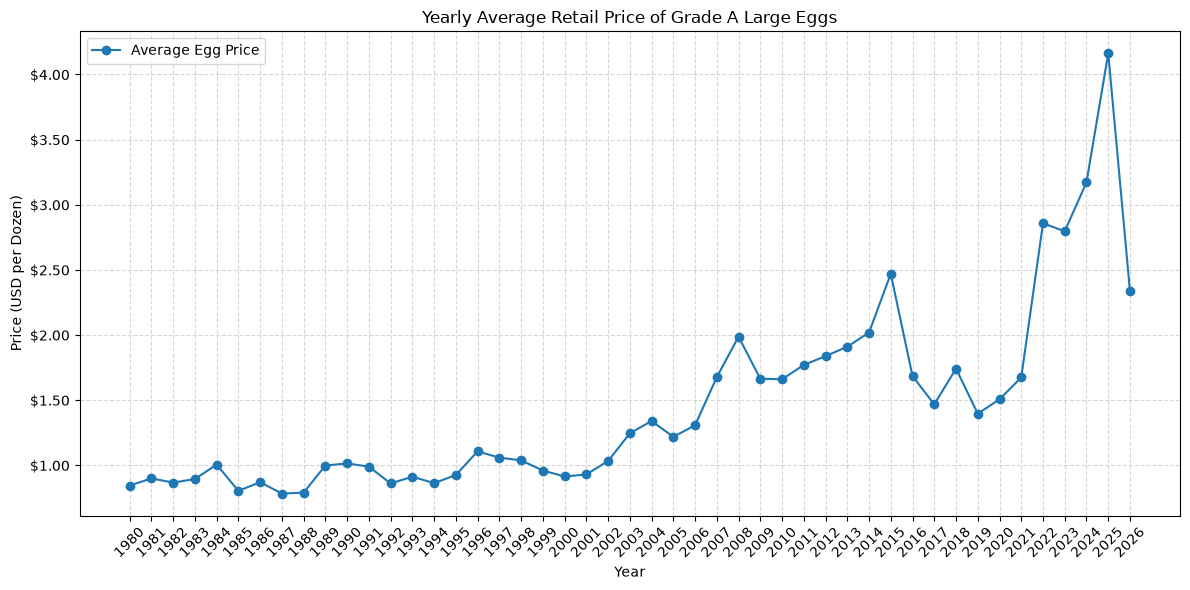

In [27]:
# Make sure date is datetime
egg["date"] = pd.to_datetime(egg["date"])

# Create a year column
egg["year"] = egg["date"].dt.year

# Calculate the average egg price for each year
egg_yearly = (
    egg.groupby("year", as_index=False)["egg_price"]
       .mean()
)

# Plot yearly averages
plt.figure(figsize=(12, 6))

plt.plot(
    egg_yearly["year"],
    egg_yearly["egg_price"],
    marker="o",
    label="Average Egg Price"
)

# Display every year on the x-axis
plt.xticks(
    egg_yearly["year"],
    rotation=45
)

# Format the y-axis as dollars
plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("${x:,.2f}")
)

plt.title("Yearly Average Retail Price of Grade A Large Eggs")
plt.xlabel("Year")
plt.ylabel("Price (USD per Dozen)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
# Egg Price Summary Statistics
summary = df['egg_price'].agg(['mean', 'median', 'std', 'min', 'max']).to_dict()
print("Summary Statistics for Egg Prices")
print("-" * 40)
for key, value in summary.items():
    print(f"{key.capitalize()}: ${value:.2f}")


Summary Statistics for Egg Prices
----------------------------------------
Mean: $1.78
Median: $1.63
Std: $0.81
Min: $0.84
Max: $6.23


### Corn 

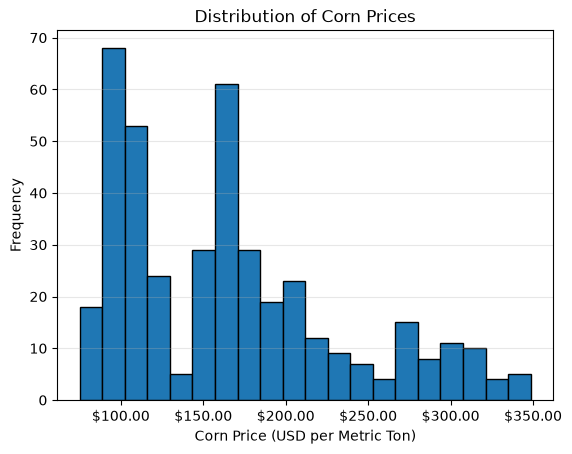

In [29]:
plt.hist(
    corn["corn_price"],
    bins=20,
    edgecolor='black'
)

plt.title("Distribution of Corn Prices")
plt.xlabel("Corn Price (USD per Metric Ton)")
plt.ylabel("Frequency")

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('${x:,.2f}'))

plt.grid(axis='y', alpha=0.3)

plt.show()

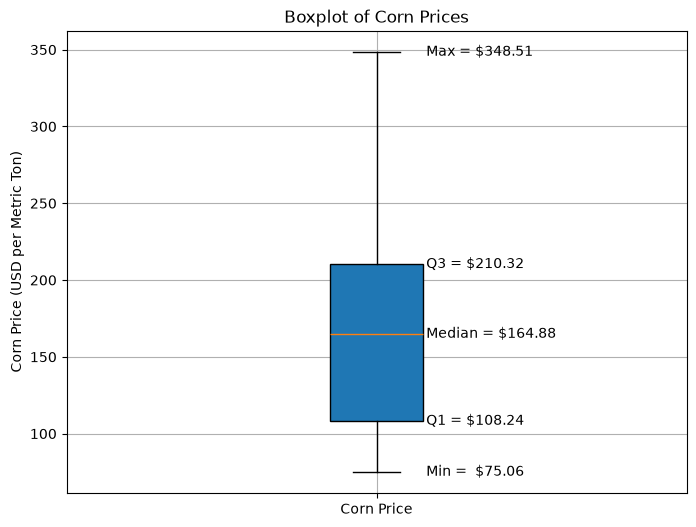

In [30]:
# Calculate quartiles
Q1 = df["corn_price"].quantile(0.25)
Median = df["corn_price"].median()
Q3 = df["corn_price"].quantile(0.75)
Minimum = df["corn_price"].min()
Maximum = df["corn_price"].max()

plt.figure(figsize=(8,6))

# Create boxplot
plt.boxplot(df["corn_price"], patch_artist=True)

# Title and labels
plt.title("Boxplot of Corn Prices")
plt.ylabel("Corn Price (USD per Metric Ton)")
plt.xticks([1], ["Corn Price"])

# Annotate the statistics
plt.text(1.08, Minimum, f"Min =  ${Minimum:.2f}", va='center')
plt.text(1.08, Q1, f"Q1 = ${Q1:.2f}", va='center')
plt.text(1.08, Median, f"Median = ${Median:.2f}", va='center')
plt.text(1.08, Q3, f"Q3 = ${Q3:.2f}", va='center')
plt.text(1.08, Maximum, f"Max = ${Maximum:.2f}", va='center')

plt.grid(True)
plt.show()

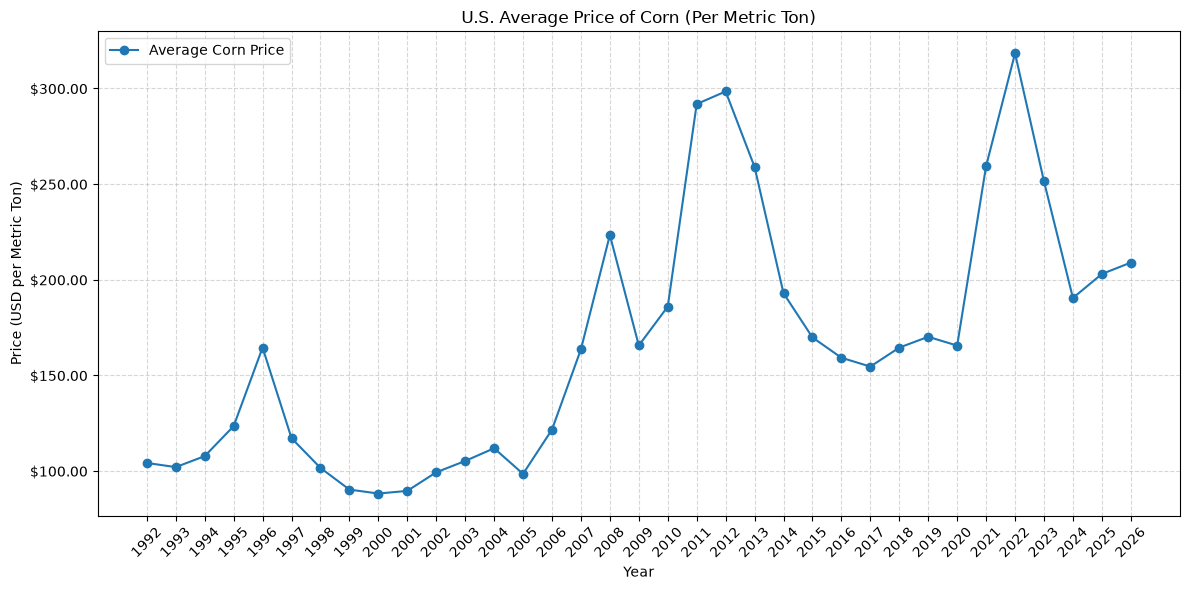

In [31]:
# Corn Price Over Time Visualization
# Make sure date is datetime
corn["date"] = pd.to_datetime(corn["date"])

# Create a year column
corn["year"] = corn["date"].dt.year

# Calculate the average corn price for each year
corn_yearly = (
    corn.groupby("year", as_index=False)["corn_price"]
       .mean()
)

# Plot yearly averages
plt.figure(figsize=(12, 6))

plt.plot(
    corn_yearly["year"],
    corn_yearly["corn_price"],
    marker="o",
    label="Average Corn Price"
)

# Display every year on the x-axis
plt.xticks(
    corn_yearly["year"],
    rotation=45
)

# Format the y-axis as dollars
plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("${x:,.2f}")
)

plt.title("U.S. Average Price of Corn (Per Metric Ton)")
plt.xlabel("Year")
plt.ylabel("Price (USD per Metric Ton)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [32]:
# Corn Price Summary Statistics
summary = df['corn_price'].agg(['mean', 'median', 'std', 'min', 'max']).to_dict()
print("Summary Statistics for Corn Prices:")
print("-" * 40)
for key, value in summary.items():
    print(f"{key.capitalize()}: ${value:.2f}")


Summary Statistics for Corn Prices:
----------------------------------------
Mean: $175.38
Median: $164.88
Std: $69.16
Min: $75.06
Max: $348.51


### Diesel 

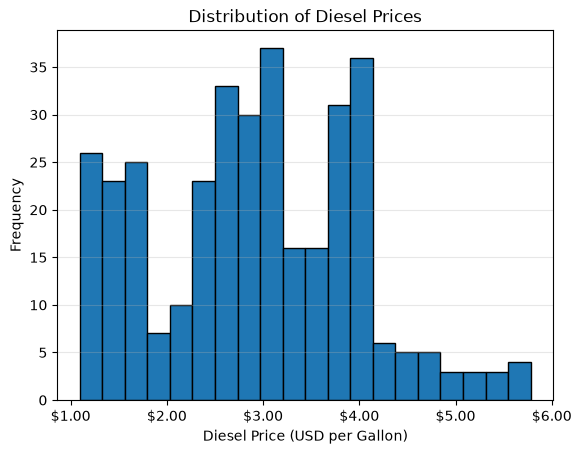

In [33]:
plt.hist(
    diesel["diesel_price"],
    bins=20,
    edgecolor='black'
)

plt.title("Distribution of Diesel Prices")
plt.xlabel("Diesel Price (USD per Gallon)")
plt.ylabel("Frequency")

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('${x:,.2f}'))

plt.grid(axis='y', alpha=0.3)

plt.show()

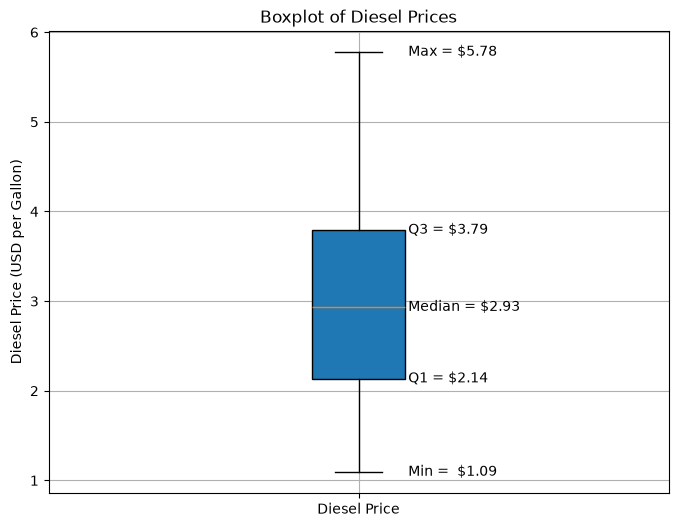

In [34]:
# Calculate quartiles
Q1 = df["diesel_price"].quantile(0.25)
Median = df["diesel_price"].median()
Q3 = df["diesel_price"].quantile(0.75)
Minimum = df["diesel_price"].min()
Maximum = df["diesel_price"].max()

plt.figure(figsize=(8,6))

# Create boxplot
plt.boxplot(df["diesel_price"], patch_artist=True)

# Title and labels
plt.title("Boxplot of Diesel Prices")
plt.ylabel("Diesel Price (USD per Gallon)")
plt.xticks([1], ["Diesel Price"])

# Annotate the statistics
plt.text(1.08, Minimum, f"Min =  ${Minimum:.2f}", va='center')
plt.text(1.08, Q1, f"Q1 = ${Q1:.2f}", va='center')
plt.text(1.08, Median, f"Median = ${Median:.2f}", va='center')
plt.text(1.08, Q3, f"Q3 = ${Q3:.2f}", va='center')
plt.text(1.08, Maximum, f"Max = ${Maximum:.2f}", va='center')

plt.grid(True)
plt.show()

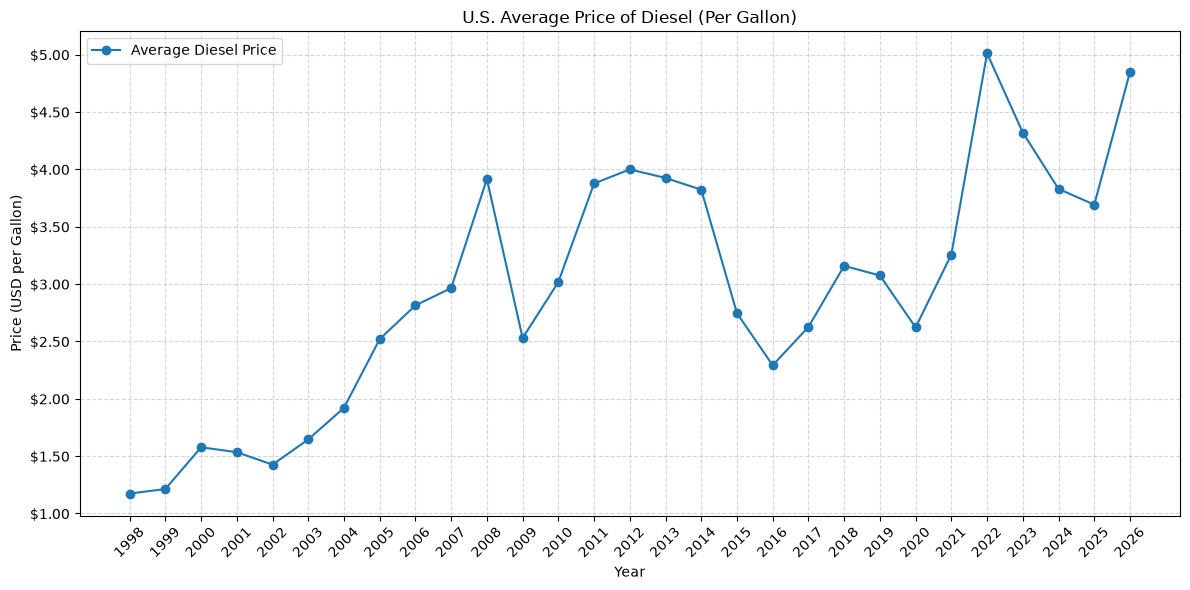

In [35]:
# Diesel Price Over Time Visualization
# Make sure date is datetime
diesel["date"] = pd.to_datetime(diesel["date"])

# Create a year column
diesel["year"] = diesel["date"].dt.year

# Calculate the average diesel price for each year
diesel_yearly = (
    diesel.groupby("year", as_index=False)["diesel_price"]
           .mean()
)

# Plot yearly averages
plt.figure(figsize=(12, 6))

plt.plot(
    diesel_yearly["year"],
    diesel_yearly["diesel_price"],
    marker="o",
    label="Average Diesel Price"
)

# Display every year on the x-axis
plt.xticks(
    diesel_yearly["year"],
    rotation=45
)

# Format the y-axis as dollars
plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("${x:,.2f}")
)

plt.title("U.S. Average Price of Diesel (Per Gallon)")
plt.xlabel("Year")
plt.ylabel("Price (USD per Gallon)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [36]:
# Diesel Price Summary Statistics
summary = df['diesel_price'].agg(['mean', 'median', 'std', 'min', 'max']).to_dict()
print("Summary Statistics for Diesel Prices:")
print("-" * 40)
for key, value in summary.items():
    print(f"{key.capitalize()}: ${value:.2f}")

Summary Statistics for Diesel Prices:
----------------------------------------
Mean: $2.91
Median: $2.93
Std: $1.06
Min: $1.09
Max: $5.78


### Soybean 

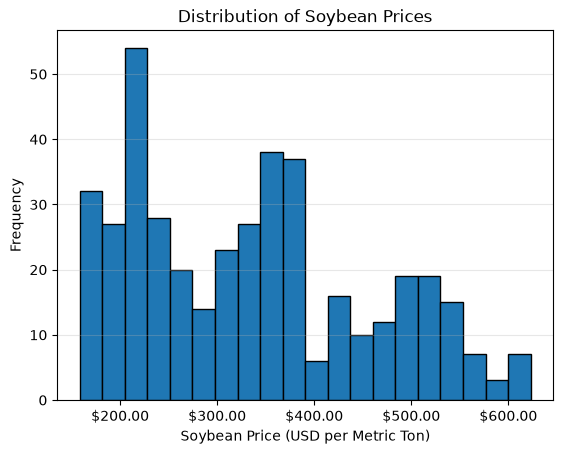

In [37]:
plt.hist(
    soybean["soybean_price"],
    bins=20,
    edgecolor='black'
)

plt.title("Distribution of Soybean Prices")
plt.xlabel("Soybean Price (USD per Metric Ton)")
plt.ylabel("Frequency")

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('${x:,.2f}'))

plt.grid(axis='y', alpha=0.3)

plt.show()

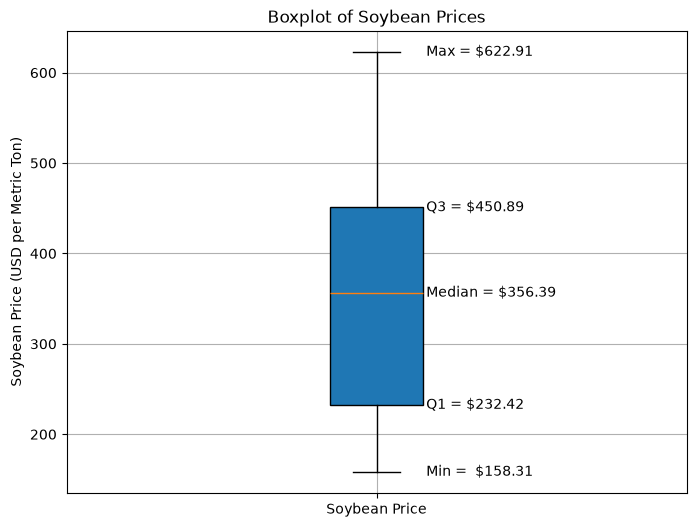

In [38]:
# Calculate quartiles
Q1 = df["soybean_price"].quantile(0.25)
Median = df["soybean_price"].median()
Q3 = df["soybean_price"].quantile(0.75)
Minimum = df["soybean_price"].min()
Maximum = df["soybean_price"].max()

plt.figure(figsize=(8,6))

# Create boxplot
plt.boxplot(df["soybean_price"], patch_artist=True)

# Title and labels
plt.title("Boxplot of Soybean Prices")
plt.ylabel("Soybean Price (USD per Metric Ton)")
plt.xticks([1], ["Soybean Price"])

# Annotate the statistics
plt.text(1.08, Minimum, f"Min =  ${Minimum:.2f}", va='center')
plt.text(1.08, Q1, f"Q1 = ${Q1:.2f}", va='center')
plt.text(1.08, Median, f"Median = ${Median:.2f}", va='center')
plt.text(1.08, Q3, f"Q3 = ${Q3:.2f}", va='center')
plt.text(1.08, Maximum, f"Max = ${Maximum:.2f}", va='center')

plt.grid(True)
plt.show()

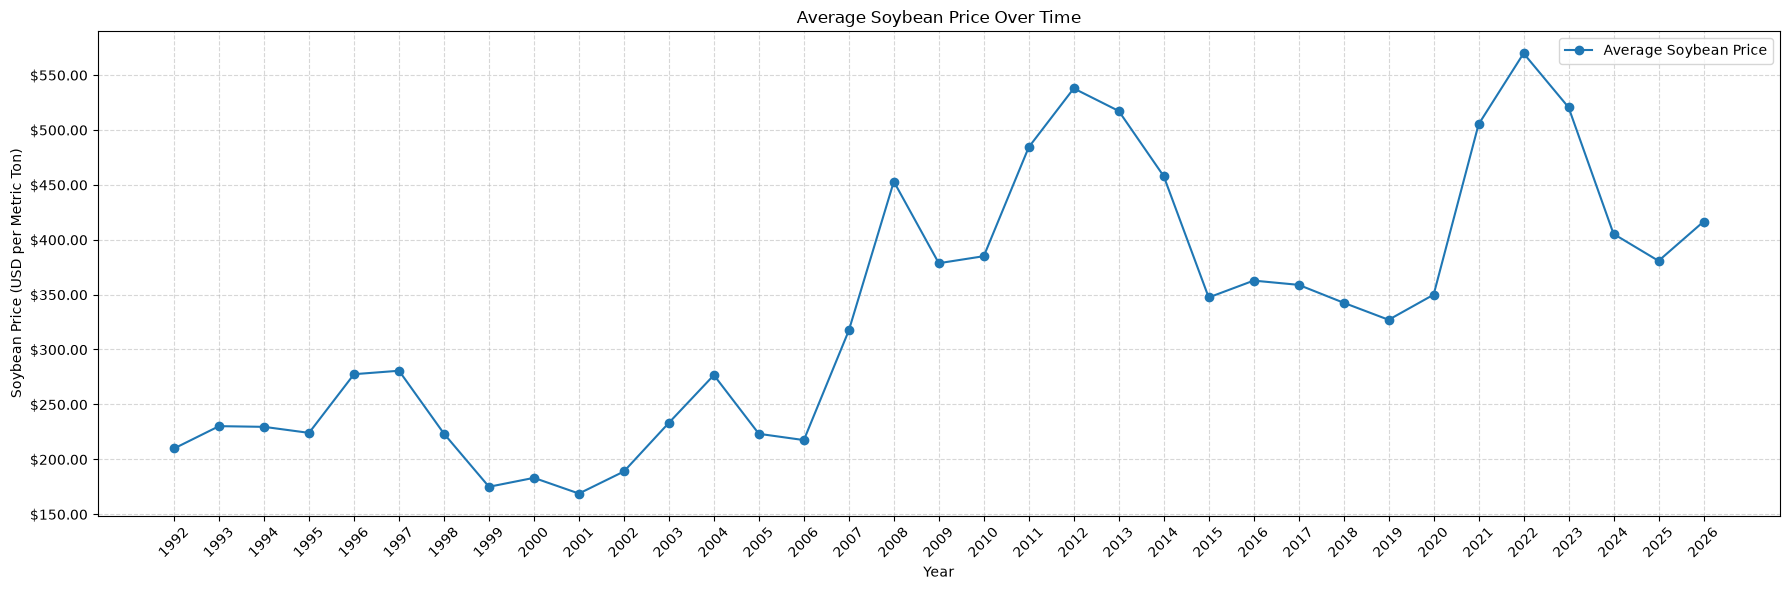

In [39]:
# Soybean  Price Over Time Visualization
# Make sure date is datetime
soybean["date"] = pd.to_datetime(soybean["date"])

# Create a year column
soybean["year"] = soybean["date"].dt.year

# Calculate the average soybean price for each year
soybean_yearly = (
    soybean.groupby("year", as_index=False)["soybean_price"]
           .mean()
)

# Plot yearly averages
plt.figure(figsize=(18, 6))

plt.plot(
    soybean_yearly["year"],
    soybean_yearly["soybean_price"],
    marker="o",
    label="Average Soybean Price"
)

# Display every year on the x-axis
plt.xticks(
    soybean_yearly["year"],
    rotation=45
)

# Format the y-axis as dollars
plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("${x:,.2f}")
)

plt.title("Average Soybean Price Over Time")
plt.xlabel("Year")
plt.ylabel("Soybean Price (USD per Metric Ton)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [40]:
# Soybean Price Summary Statistics
summary = df['soybean_price'].agg(['mean', 'median', 'std', 'min', 'max']).to_dict()
print("Summary Statistics for Soybean Prices:")
print("-" * 40)
for key, value in summary.items():
    print(f"{key.capitalize()}: ${value:.2f}")

Summary Statistics for Soybean Prices:
----------------------------------------
Mean: $354.31
Median: $356.39
Std: $124.12
Min: $158.31
Max: $622.91


### CPI

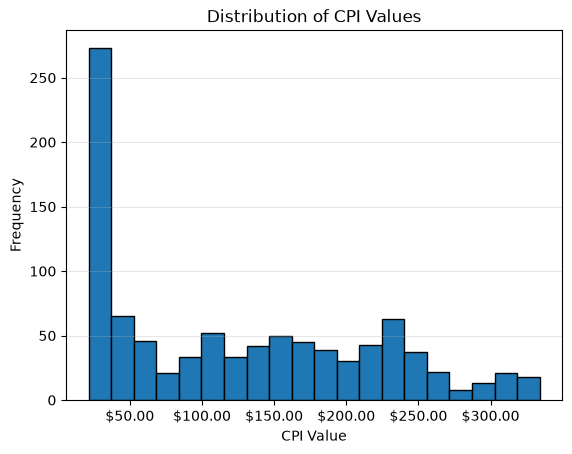

In [41]:
plt.hist(
    cpi["cpi"],
    bins=20,
    edgecolor='black'
)

plt.title("Distribution of CPI Values")
plt.xlabel("CPI Value")
plt.ylabel("Frequency")

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('${x:,.2f}'))

plt.grid(axis='y', alpha=0.3)

plt.show()

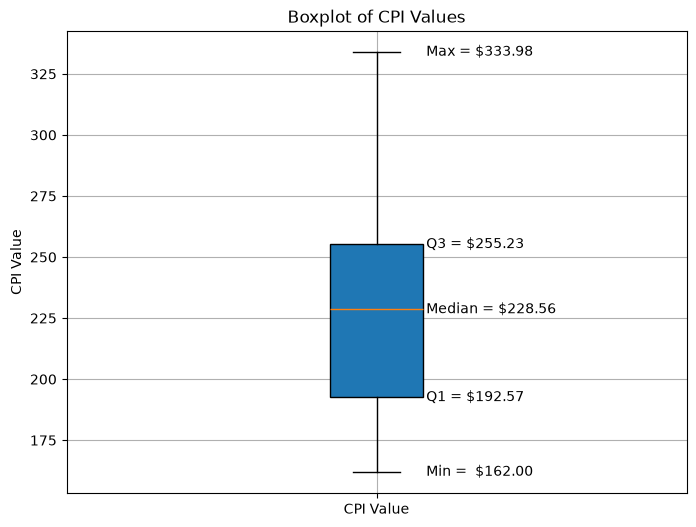

In [42]:
# Calculate quartiles
Q1 = df["cpi"].quantile(0.25)
Median = df["cpi"].median()
Q3 = df["cpi"].quantile(0.75)
Minimum = df["cpi"].min()
Maximum = df["cpi"].max()

plt.figure(figsize=(8,6))

# Create boxplot
plt.boxplot(df["cpi"], patch_artist=True)

# Title and labels
plt.title("Boxplot of CPI Values")
plt.ylabel("CPI Value")
plt.xticks([1], ["CPI Value"])

# Annotate the statistics
plt.text(1.08, Minimum, f"Min =  ${Minimum:.2f}", va='center')
plt.text(1.08, Q1, f"Q1 = ${Q1:.2f}", va='center')
plt.text(1.08, Median, f"Median = ${Median:.2f}", va='center')
plt.text(1.08, Q3, f"Q3 = ${Q3:.2f}", va='center')
plt.text(1.08, Maximum, f"Max = ${Maximum:.2f}", va='center')

plt.grid(True)
plt.show()

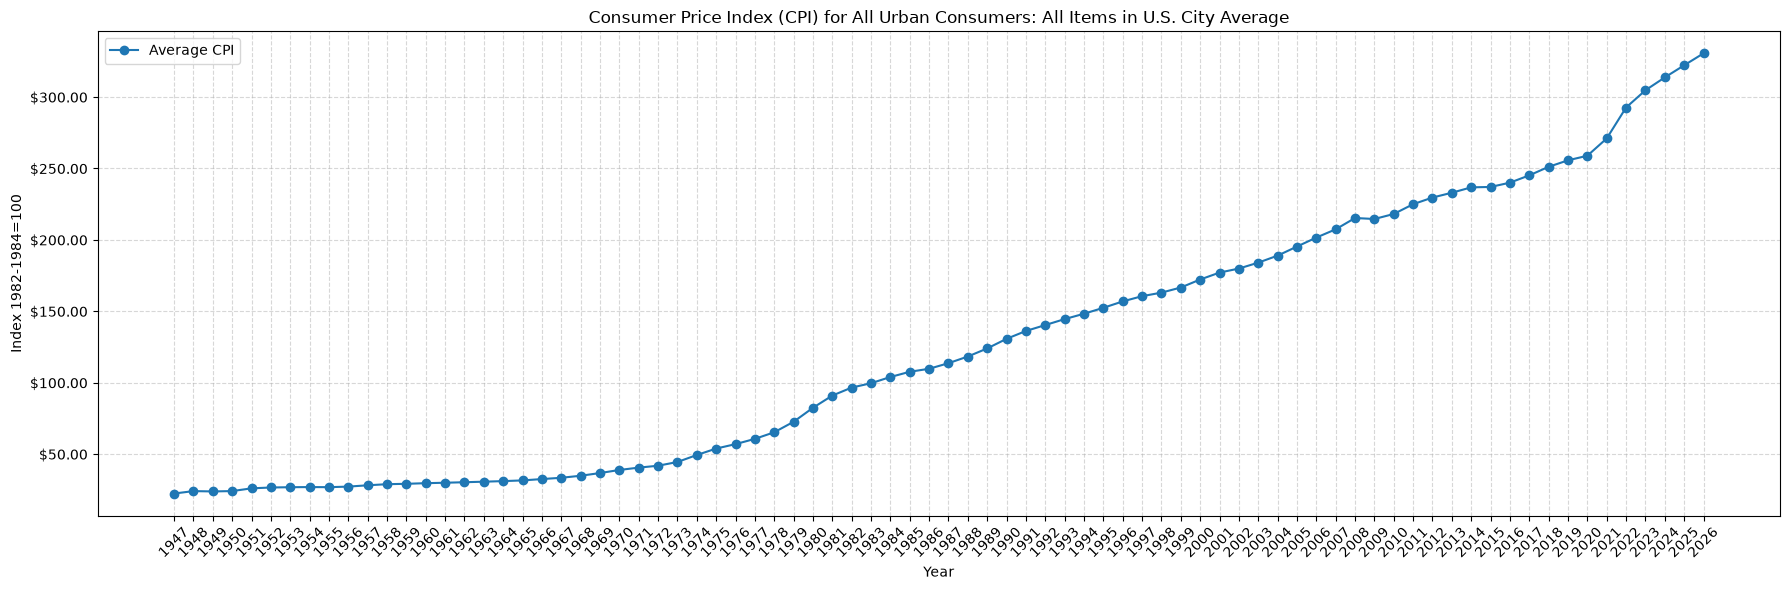

In [43]:
# CPI Price Over Time Visualization
# Make sure date is datetime
cpi["date"] = pd.to_datetime(cpi["date"])

# Create a year column
cpi["year"] = cpi["date"].dt.year

# Calculate the average cpi for each year
cpi_yearly = (
    cpi.groupby("year", as_index=False)["cpi"]
       .mean()
)

# Plot yearly averages
plt.figure(figsize=(18, 6))

plt.plot(
    cpi_yearly["year"],
    cpi_yearly["cpi"],
    marker="o",
    label="Average CPI"
)

# Display every year on the x-axis
plt.xticks(
    cpi_yearly["year"],
    rotation=45
)

# Format the y-axis as dollars
plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("${x:,.2f}")
)

plt.title("Consumer Price Index (CPI) for All Urban Consumers: All Items in U.S. City Average")
plt.xlabel("Year")
plt.ylabel("Index 1982-1984=100")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [44]:
# CPI Price Summary Statistics
summary = df['cpi'].agg(['mean', 'median', 'std', 'min', 'max']).to_dict()
print("Summary Statistics for CPI:")
print("-" * 40)
for key, value in summary.items():
    print(f"{key.capitalize()}: ${value:.2f}")

Summary Statistics for CPI:
----------------------------------------
Mean: $230.35
Median: $228.56
Std: $45.32
Min: $162.00
Max: $333.98


### Bird Flu

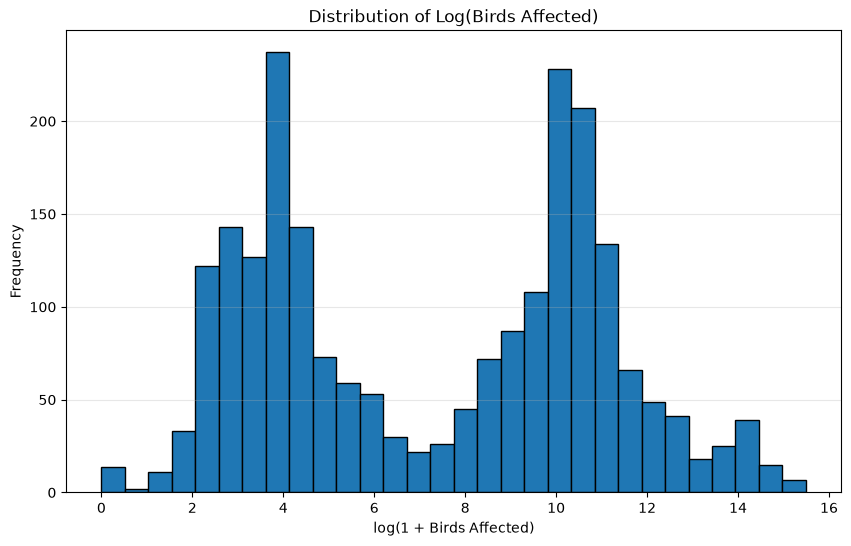

In [45]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    np.log1p(bird_flu["bird_affected"]),
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Log(Birds Affected)")
plt.xlabel("log(1 + Birds Affected)")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.show()

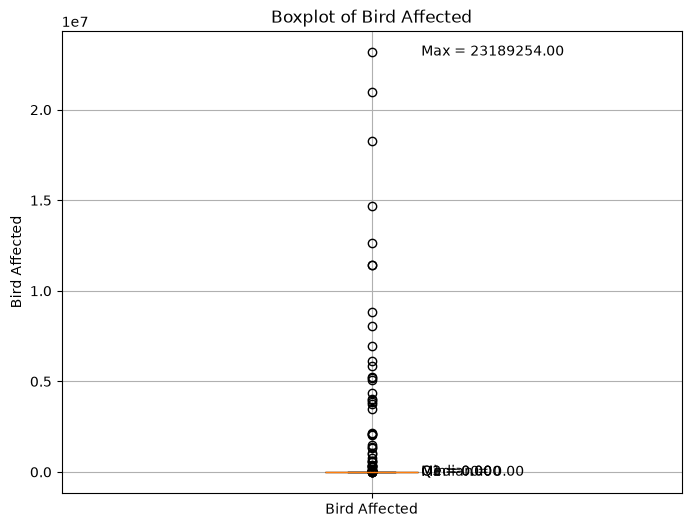

In [46]:
# Calculate quartiles
Q1 = df["bird_affected"].quantile(0.25)
Median = df["bird_affected"].median()
Q3 = df["bird_affected"].quantile(0.75)
Minimum = df["bird_affected"].min()
Maximum = df["bird_affected"].max()

plt.figure(figsize=(8,6))

# Create boxplot
plt.boxplot(df["bird_affected"], patch_artist=True)

# Title and labels
plt.title("Boxplot of Bird Affected")
plt.ylabel("Bird Affected")
plt.xticks([1], ["Bird Affected"])

# Annotate the statistics
plt.text(1.08, Minimum, f"Min =  {Minimum:.2f}", va='center')
plt.text(1.08, Q1, f"Q1 = {Q1:.2f}", va='center')
plt.text(1.08, Median, f"Median = {Median:.2f}", va='center')
plt.text(1.08, Q3, f"Q3 = {Q3:.2f}", va='center')
plt.text(1.08, Maximum, f"Max = {Maximum:.2f}", va='center')

plt.grid(True)
plt.show()

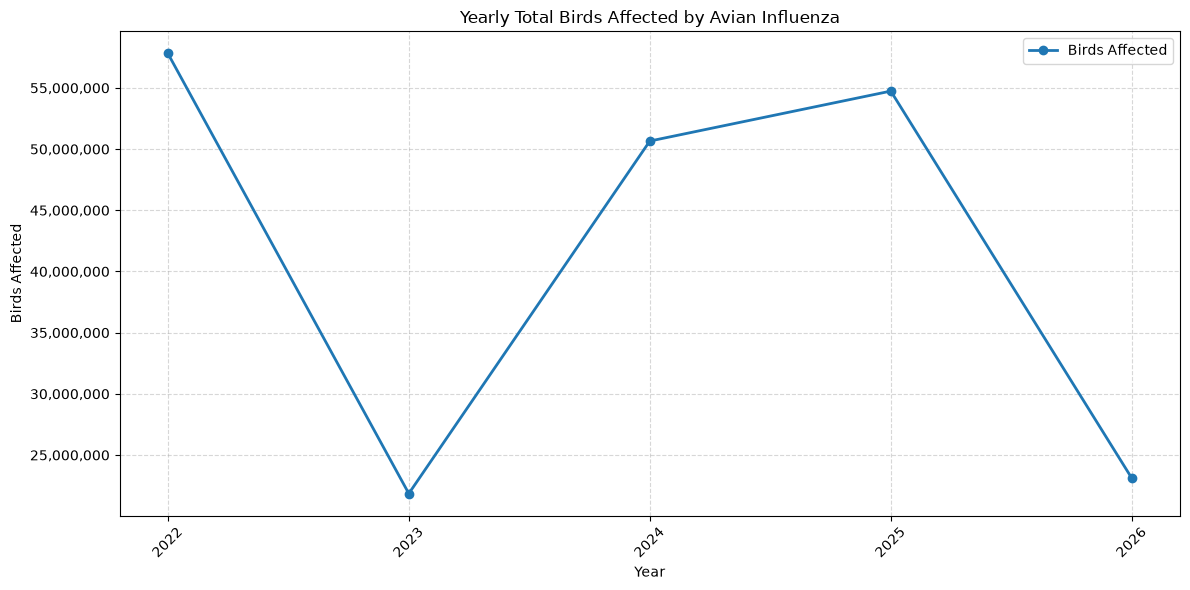

In [47]:
# Make sure date is datetime
# Make sure date is datetime
bird_flu["date"] = pd.to_datetime(bird_flu["date"])

# Create year column
bird_flu["year"] = bird_flu["date"].dt.year

# Total birds affected per year
bird_flu_yearly = (
    bird_flu.groupby("year", as_index=False)["bird_affected"]
            .sum()
)

# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    bird_flu_yearly["year"],
    bird_flu_yearly["bird_affected"],
    marker="o",
    linewidth=2,
    label="Birds Affected"
)

# Show every year
plt.xticks(
    bird_flu_yearly["year"],
    rotation=45
)

# Format large numbers with commas
plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

plt.title("Yearly Total Birds Affected by Avian Influenza")
plt.xlabel("Year")
plt.ylabel("Birds Affected")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [48]:
# Bird Flu Summary Statistics
summary = df["bird_affected"].agg(
    ["mean", "median", "std", "min", "max"]
).to_dict()

print("Summary Statistics for Bird Flu Cases")
print("-" * 40)

for key, value in summary.items():
    print(f"{key.capitalize():<10}: {value:,.0f}")

Summary Statistics for Bird Flu Cases
----------------------------------------
Mean      : 604,341
Median    : 0
Std       : 2,588,445
Min       : 0
Max       : 23,189,254


## Scatter Plot 

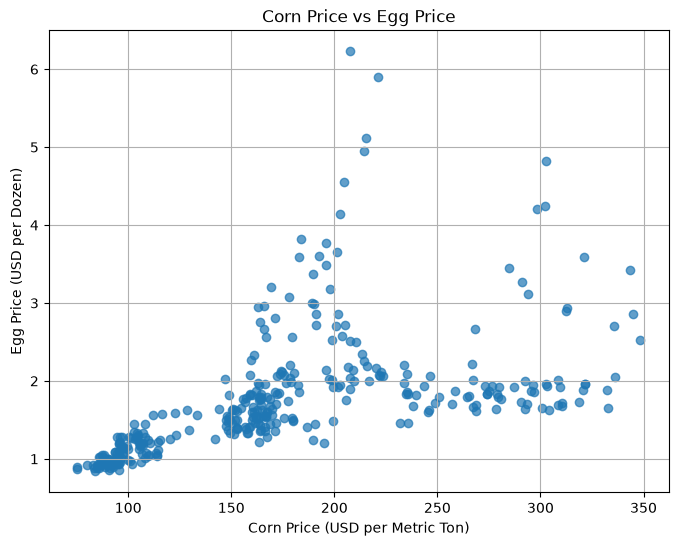

In [49]:
# When corn price increases, egg price also increases. 
# This is because corn is a major feed for chickens, and when the cost of feed goes up, it can lead to higher production costs for eggs, which in turn can result in higher egg prices for consumers.
# Egg Price vs Corn Price Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    df["corn_price"],
    df["egg_price"],
    alpha=0.7
)

plt.title("Corn Price vs Egg Price")
plt.xlabel("Corn Price (USD per Metric Ton)")
plt.ylabel("Egg Price (USD per Dozen)")
plt.grid(True)


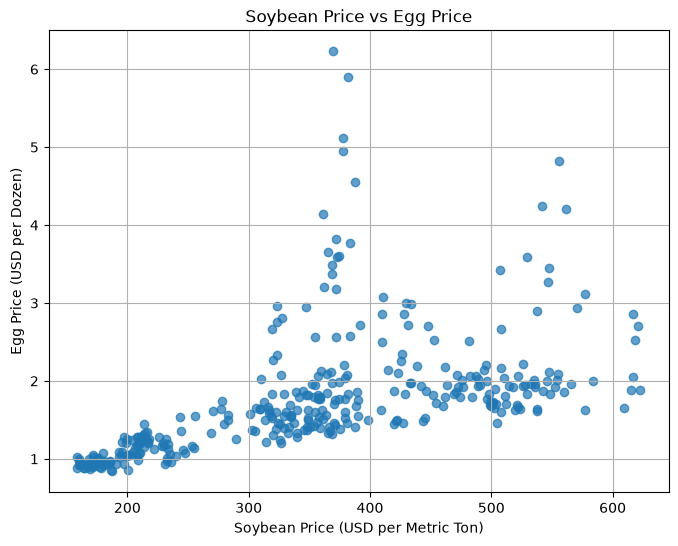

In [50]:
# When soybean price increases, egg price also increases.
# This is because soybeans are a major feed for chickens, and when the cost of feed goes up, it can lead to higher production costs for eggs, 
# which in turn can result in higher egg prices for consumers.
# Egg Price vs Soybean Price Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    df["soybean_price"],
    df["egg_price"],
    alpha=0.7
)

plt.title("Soybean Price vs Egg Price")
plt.xlabel("Soybean Price (USD per Metric Ton)")
plt.ylabel("Egg Price (USD per Dozen)")
plt.grid(True)


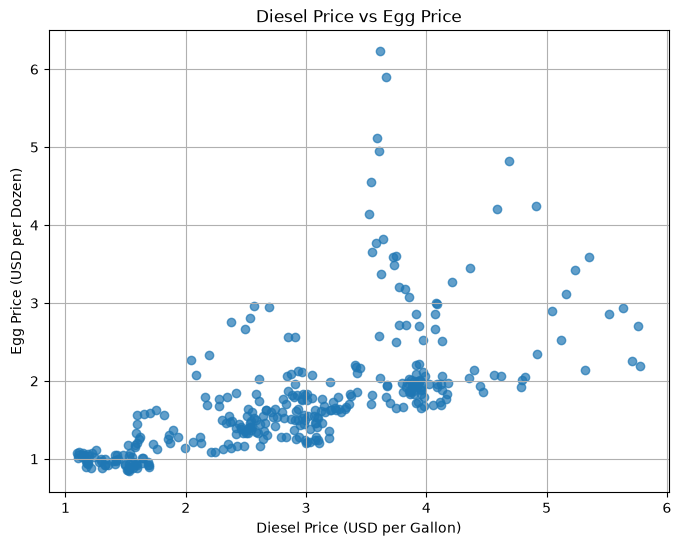

In [51]:
# When diesel price increases, egg price also increases.
# This is because diesel is a major fuel for transportation, and when the cost of fuel goes up, it can lead to higher transportation costs for eggs, 
# which in turn can result in higher egg prices for consumers.
# Egg Price vs Diesel Price Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    df["diesel_price"],
    df["egg_price"],
    alpha=0.7
)

plt.title("Diesel Price vs Egg Price")
plt.xlabel("Diesel Price (USD per Gallon)")
plt.ylabel("Egg Price (USD per Dozen)")
plt.grid(True)


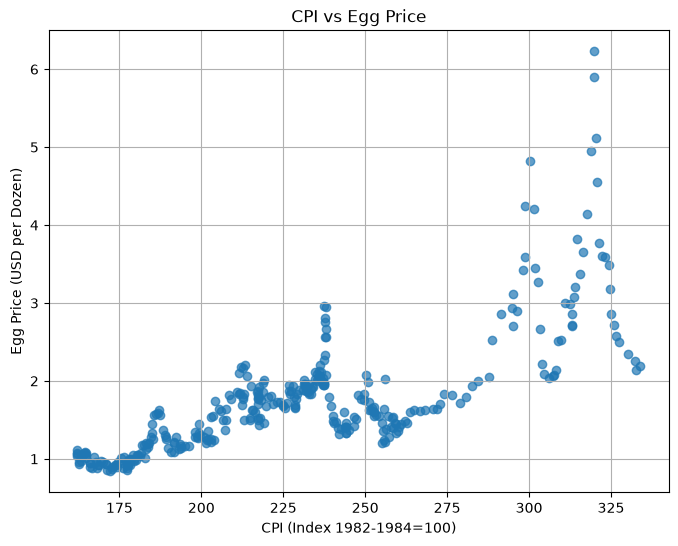

In [52]:
# When CPI increases, egg price also increases.
# This is because CPI is a measure of the average change in prices paid by consumers for goods and services, 
# and when the overall price level rises, it can lead to higher production costs for eggs, which in turn can result in higher egg prices for consumers.
# Egg Price vs CPI Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    df["cpi"],
    df["egg_price"],
    alpha=0.7
)

plt.title("CPI vs Egg Price")
plt.xlabel("CPI (Index 1982-1984=100)")
plt.ylabel("Egg Price (USD per Dozen)")
plt.grid(True)


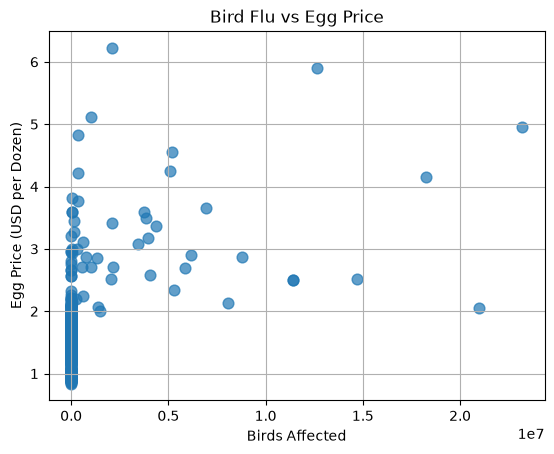

In [53]:
# Bird Flu vs Egg Price Scatter Plot
# Each point represents one year.
# This plot explores whether years with more birds affected by avian influenza
# tend to have higher average egg prices.
plt.scatter(
    df["bird_affected"],
    df["egg_price"],
    alpha=0.7,
    s=60
)

plt.title("Bird Flu vs Egg Price")
plt.xlabel("Birds Affected")
plt.ylabel("Egg Price (USD per Dozen)")
plt.grid(True)

plt.show()

### Graph "Egg Price and Production-Cost Trends Over Time"

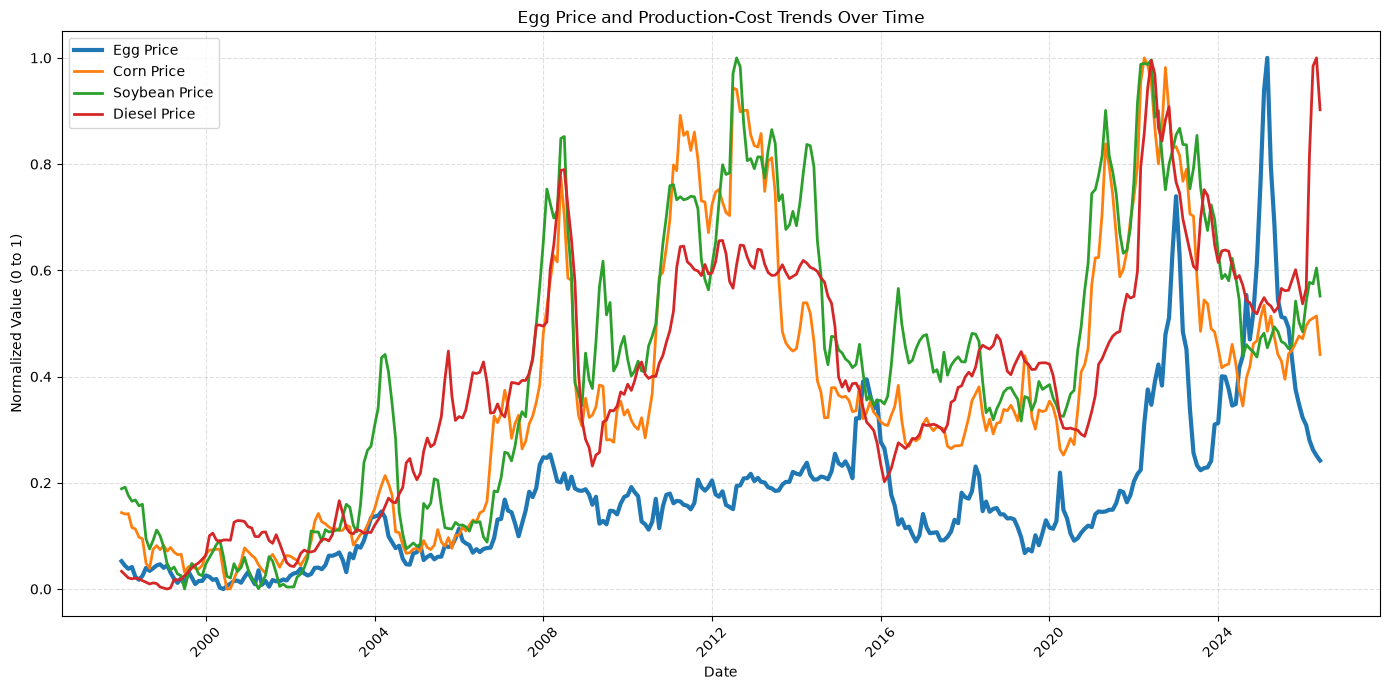

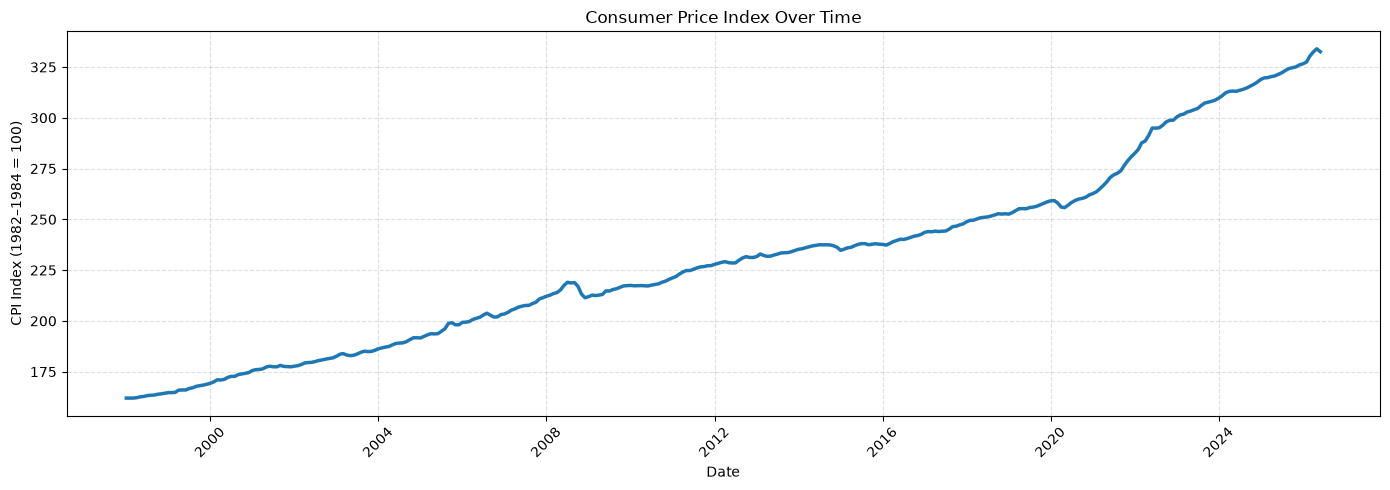

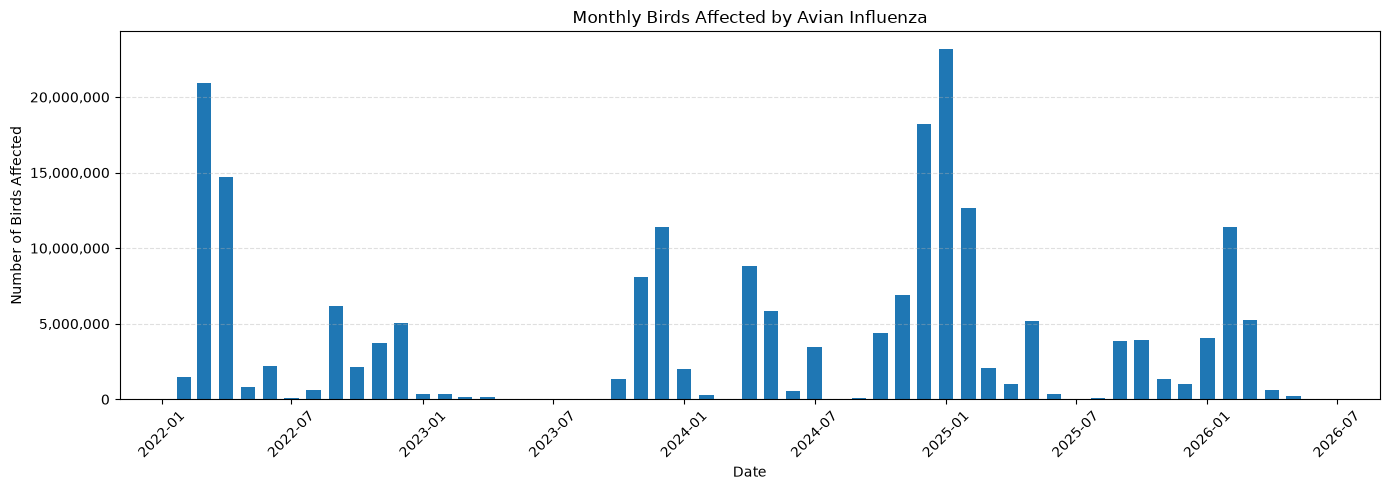

In [54]:

# --------------------------------------------------
# 1. Prepare the data
# --------------------------------------------------

columns = [
    "egg_price",
    "corn_price",
    "soybean_price",
    "diesel_price",
    "cpi",
    "bird_affected"
]

graph_df = df[["date"] + columns].copy()

# Convert date column
graph_df["date"] = pd.to_datetime(
    graph_df["date"],
    errors="coerce"
)

# Convert all variables to numeric
for column in columns:
    graph_df[column] = pd.to_numeric(
        graph_df[column],
        errors="coerce"
    )

# Sort by date
graph_df = graph_df.sort_values("date")

# Fill missing price and CPI values
price_columns = [
    "egg_price",
    "corn_price",
    "soybean_price",
    "diesel_price",
    "cpi"
]

graph_df[price_columns] = (
    graph_df[price_columns]
    .interpolate(method="linear")
    .ffill()
    .bfill()
)

# Months without bird-flu records are treated as zero
graph_df["bird_affected"] = (
    graph_df["bird_affected"]
    .fillna(0)
)

# Remove rows without dates
graph_df = graph_df.dropna(subset=["date"])


# --------------------------------------------------
# 2. Graph 1: Egg, corn, soybean, and diesel trends
# --------------------------------------------------

price_graph_columns = [
    "egg_price",
    "corn_price",
    "soybean_price",
    "diesel_price"
]

# Normalize only the variables shown on this graph
price_scaler = MinMaxScaler()

normalized_prices = graph_df.copy()

normalized_prices[price_graph_columns] = (
    price_scaler.fit_transform(
        normalized_prices[price_graph_columns]
    )
)

plt.figure(figsize=(14, 7))

plt.plot(
    normalized_prices["date"],
    normalized_prices["egg_price"],
    label="Egg Price",
    linewidth=3
)

plt.plot(
    normalized_prices["date"],
    normalized_prices["corn_price"],
    label="Corn Price",
    linewidth=2
)

plt.plot(
    normalized_prices["date"],
    normalized_prices["soybean_price"],
    label="Soybean Price",
    linewidth=2
)

plt.plot(
    normalized_prices["date"],
    normalized_prices["diesel_price"],
    label="Diesel Price",
    linewidth=2
)

plt.title("Egg Price and Production-Cost Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Normalized Value (0 to 1)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 3. Graph 2: CPI over time
# --------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    graph_df["date"],
    graph_df["cpi"],
    linewidth=2.5
)

plt.title("Consumer Price Index Over Time")
plt.xlabel("Date")
plt.ylabel("CPI Index (1982–1984 = 100)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 4. Graph 3: Birds affected by avian influenza
# --------------------------------------------------

# Make sure date is stored correctly
graph_df["date"] = pd.to_datetime(graph_df["date"])

# Keep only dates with reported affected birds
# Create monthly totals
monthly_bird_flu = (
    graph_df
    .set_index("date")["bird_affected"]
    .resample("MS")
    .sum()
    .reset_index()
)

# Remove months with no outbreaks
monthly_bird_flu = monthly_bird_flu[
    monthly_bird_flu["bird_affected"] > 0
]

plt.figure(figsize=(14, 5))

plt.bar(
    monthly_bird_flu["date"],
    monthly_bird_flu["bird_affected"],
    width=20
)

plt.title("Monthly Birds Affected by Avian Influenza")
plt.xlabel("Date")
plt.ylabel("Number of Birds Affected")

plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Correlation Heatmap

In [55]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Remove rows that are completely duplicated
df = df.drop_duplicates()

# Sort by date
df = df.sort_values("date").reset_index(drop=True)

print(df.head(15))
print("Number of rows:", len(df))

         date  egg_price  corn_price  soybean_price  diesel_price    cpi  \
0  1998-01-01      1.120  114.367256     246.000675         1.250  162.0   
1  1998-02-01      1.073  113.618736     247.424636         1.220  162.0   
2  1998-03-01      1.043  113.840439     240.121096         1.192  162.0   
3  1998-04-01      1.061  106.687859     235.091300         1.184  162.2   
4  1998-05-01      0.960  105.966927     236.147786         1.190  162.6   
5  1998-06-01      0.932  101.751694     231.117990         1.185  162.8   
6  1998-07-01      0.971  100.904480     232.427115         1.168  163.2   
7  1998-08-01      1.053   88.358208     202.248338         1.154  163.4   
8  1998-09-01      1.022   85.714447     193.337100         1.138  163.5   
9  1998-10-01      1.048   95.494759     200.755476         1.148  163.9   
10 1998-11-01      1.077   97.384529     209.896384         1.142  164.1   
11 1998-12-01      1.089   95.324760     204.912522         1.112  164.4   
12 1999-01-0

egg_price        1.000000
cpi              0.768029
diesel_price     0.636708
corn_price       0.546008
soybean_price    0.535867
bird_affected    0.467803
Name: egg_price, dtype: float64


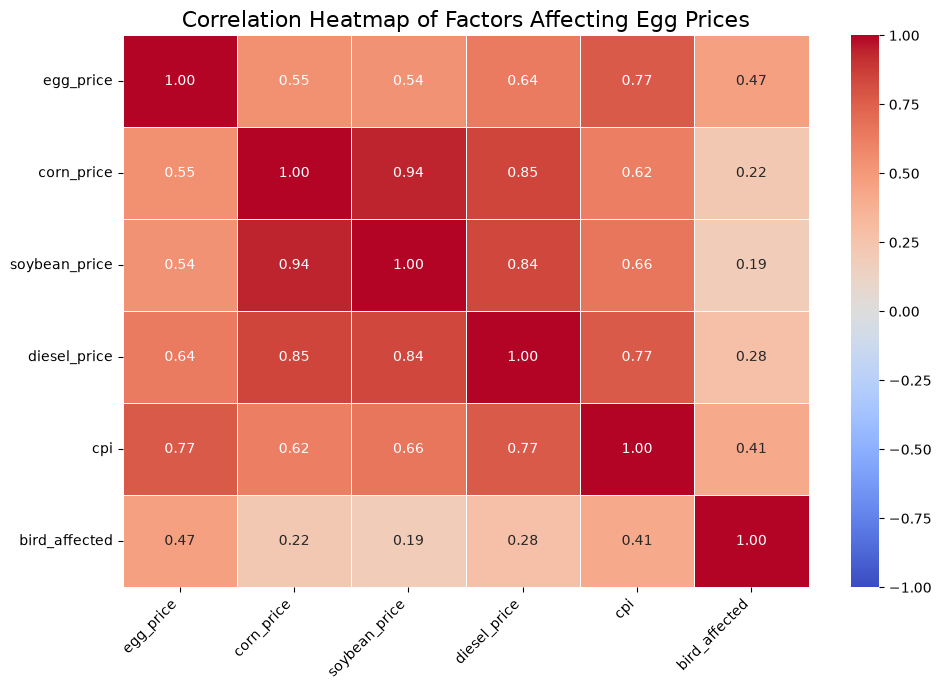

In [56]:
# Purpose:
# This code calculates the correlation between egg prices and other variables
# (corn price, soybean price, diesel price, CPI, and birds affected by bird flu).
# The correlation matrix helps identify which variables have the strongest
# positive or negative relationship with egg prices. A heatmap is then created
# to visually display these relationships, making it easier to interpret the data
# during Exploratory Data Analysis (EDA) before building a machine learning model.
# Select the variables
# Import Seaborn for the heatmap
data = df[[
    "egg_price",
    "corn_price",
    "soybean_price",
    "diesel_price",
    "cpi",
    "bird_affected"
]]

correlation = data.corr()

print(correlation["egg_price"].sort_values(ascending=False))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Factors Affecting Egg Prices", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# 9. Feature Engineering

Two new features were created for the project. The `bird_flu_outbreak`
feature indicates whether a bird flu outbreak occurred during a month.
The `inflation_rate` feature measures the year-over-year percentage
change in the Consumer Price Index.

## Bird Flu Outbreak 

In [57]:
# Create a binary bird flu outbreak feature
# 0 = No birds affected
# 1 = One or more birds affected

df["bird_flu_outbreak"] = (df["bird_affected"] > 0).astype(int)

In [58]:
# Check the first 20 rows of the new feature
print(df[[
    "date",
    "bird_affected",
    "bird_flu_outbreak"
]].head(20))

         date  bird_affected  bird_flu_outbreak
0  1998-01-01            0.0                  0
1  1998-02-01            0.0                  0
2  1998-03-01            0.0                  0
3  1998-04-01            0.0                  0
4  1998-05-01            0.0                  0
5  1998-06-01            0.0                  0
6  1998-07-01            0.0                  0
7  1998-08-01            0.0                  0
8  1998-09-01            0.0                  0
9  1998-10-01            0.0                  0
10 1998-11-01            0.0                  0
11 1998-12-01            0.0                  0
12 1999-01-01            0.0                  0
13 1999-02-01            0.0                  0
14 1999-03-01            0.0                  0
15 1999-04-01            0.0                  0
16 1999-05-01            0.0                  0
17 1999-06-01            0.0                  0
18 1999-07-01            0.0                  0
19 1999-08-01            0.0            

In [59]:
# Check the distribution of the new feature
print(df["bird_flu_outbreak"].value_counts())

bird_flu_outbreak
0    290
1     52
Name: count, dtype: int64


### Inflation Rate 

In [60]:
# Calculate year-over-year inflation rate from monthly CPI
df["inflation_rate"] = (
    df["cpi"].pct_change(periods=12) * 100
)

# Remove the first 12 rows that do not have a year-over-year value
df = df.dropna(
    subset=["inflation_rate"]
).reset_index(drop=True)

# Review the engineered features
print(
    df[[
        "date",
        "cpi",
        "inflation_rate",
        "bird_affected",
        "bird_flu_outbreak"
    ]].head()
)

        date    cpi  inflation_rate  bird_affected  bird_flu_outbreak
0 1999-01-01  164.7        1.666667            0.0                  0
1 1999-02-01  164.7        1.666667            0.0                  0
2 1999-03-01  164.8        1.728395            0.0                  0
3 1999-04-01  165.9        2.281134            0.0                  0
4 1999-05-01  166.0        2.091021            0.0                  0


# 10. Train/Test Split

In [61]:
# Purpose:
# Split the dataset into training and testing sets.
# The training set (80%) is used to train the machine learning model,
# while the testing set (20%) is used to evaluate how well the model
# performs on unseen data.
# Select the input features (X)
X = df[[
    "corn_price",
    "soybean_price",
    "diesel_price",
    "cpi",
    "inflation_rate",
    "bird_affected",
    "bird_flu_outbreak"   # Remove this line if you did not create this feature
]]

# Select the target variable (y)
y = df["egg_price"]

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the size of each dataset
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (264, 7)
Testing Features : (66, 7)
Training Target  : (264,)
Testing Target   : (66,)


# 11. Data Preprocessing

In [62]:
# Purpose:
# Prepare the training and testing data for machine learning.
# Missing values are replaced with the median of each feature,
# and the data is standardized so that all features have a
# similar scale. The preprocessing is fit only on the training
# data and then applied to the testing data to avoid data leakage.
# Create a preprocessing pipeline
preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # Fill missing values
    ("scaler", StandardScaler())                    # Standardize the features
])

# Fit the preprocessing pipeline on the training data
X_train_prepared = preprocessing.fit_transform(X_train)

# Apply the same preprocessing to the test data
X_test_prepared = preprocessing.transform(X_test)

# Display the shape of the processed datasets
print("Training data shape:", X_train_prepared.shape)
print("Testing data shape :", X_test_prepared.shape)

Training data shape: (264, 7)
Testing data shape : (66, 7)


# 12. Model Training 

## Linear Regression Model 

In [63]:
# Create the model
linear_model = LinearRegression()

# Train the model using the prepared training data
linear_model.fit(X_train_prepared, y_train)

linear_predictions = linear_model.predict(X_test_prepared)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [64]:
# Linear Regression predictions
linear_predictions = linear_model.predict(X_test_prepared)

# Calculate evaluation metrics
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("--------------------------")
print("MAE :", round(linear_mae, 3))
print("RMSE:", round(linear_rmse, 3))
print("R²  :", round(linear_r2, 3))

Linear Regression Results
--------------------------
MAE : 0.303
RMSE: 0.451
R²  : 0.697


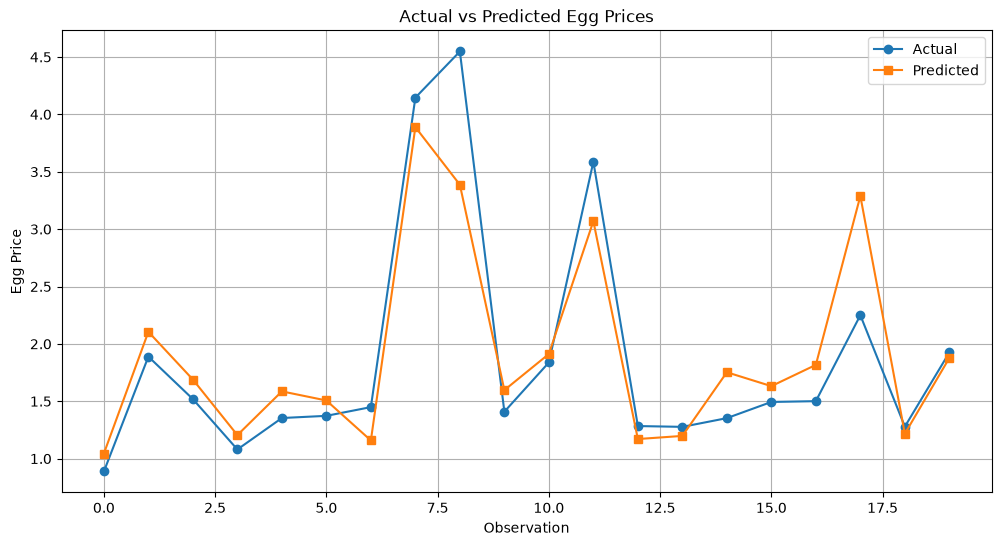

In [65]:
# Compare actual and predicted values
results = pd.DataFrame({
    "Actual Egg Price": y_test,
    "Predicted Egg Price": linear_predictions
})
plt.figure(figsize=(12, 6))

plt.plot(
    y_test.values[:20],
    marker="o",
    label="Actual"
)

plt.plot(
    linear_predictions[:20],
    marker="s",
    label="Predicted"
)

plt.title("Actual vs Predicted Egg Prices")
plt.xlabel("Observation")
plt.ylabel("Egg Price")

plt.legend()
plt.grid(True)

plt.show()


## Decision Tree Regressor

In [66]:
# Create the model
tree_model = DecisionTreeRegressor(random_state=42)

# Train the model
tree_model.fit(X_train_prepared, y_train)

# Make predictions
tree_predictions = tree_model.predict(X_test_prepared)

In [67]:
# Tree Regression predictions
tree_predictions = tree_model.predict(X_test_prepared)

# Calculate evaluation metrics
tree_mae = mean_absolute_error(y_test, tree_predictions)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_predictions))
tree_r2 = r2_score(y_test, tree_predictions)

print("Tree Regression Results")
print("--------------------------")
print("MAE :", round(tree_mae, 3))
print("RMSE:", round(tree_rmse, 3))
print("R²  :", round(tree_r2, 3))

Tree Regression Results
--------------------------
MAE : 0.167
RMSE: 0.231
R²  : 0.921


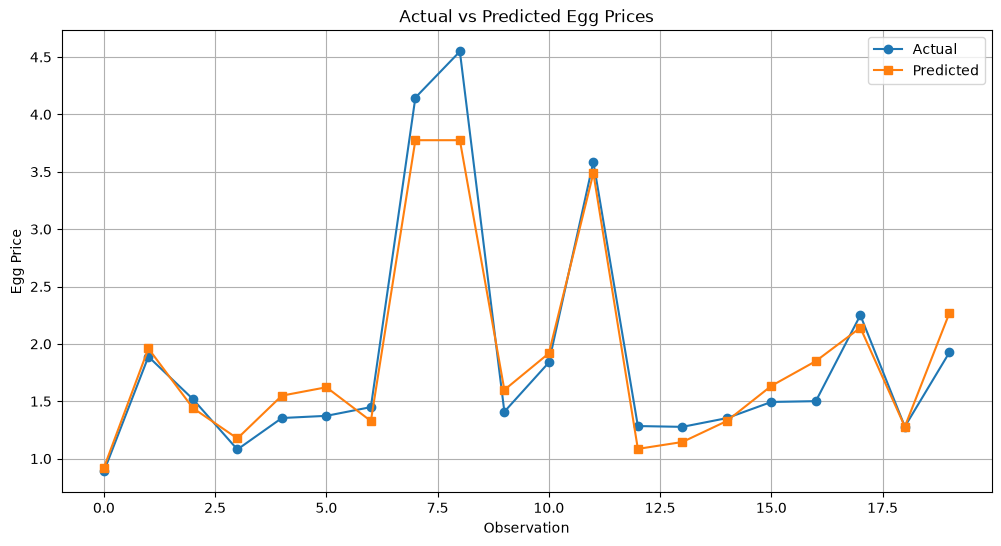

In [68]:
# Compare actual and predicted values
results = pd.DataFrame({
    "Actual Egg Price": y_test,
    "Predicted Egg Price": tree_predictions
})
plt.figure(figsize=(12, 6))

plt.plot(
    y_test.values[:20],
    marker="o",
    label="Actual"
)

plt.plot(
    tree_predictions[:20],
    marker="s",
    label="Predicted"
)

plt.title("Actual vs Predicted Egg Prices")
plt.xlabel("Observation")
plt.ylabel("Egg Price")

plt.legend()
plt.grid(True)

plt.show()

## Random Forest Regressor

In [69]:
# Create the model
forest_model = RandomForestRegressor(
    random_state=42
)

# Train the model
forest_model.fit(X_train_prepared, y_train)

# Make predictions
forest_predictions = forest_model.predict(X_test_prepared)

In [70]:
# Forest Regression predictions
forest_predictions = forest_model.predict(X_test_prepared)

# Calculate evaluation metrics
forest_mae = mean_absolute_error(y_test, forest_predictions)
forest_rmse = np.sqrt(mean_squared_error(y_test, forest_predictions))
forest_r2 = r2_score(y_test, forest_predictions)

print("Forest Regression Results")
print("--------------------------")
print("MAE :", round(forest_mae, 3))
print("RMSE:", round(forest_rmse, 3))
print("R²  :", round(forest_r2, 3))

Forest Regression Results
--------------------------
MAE : 0.149
RMSE: 0.235
R²  : 0.918


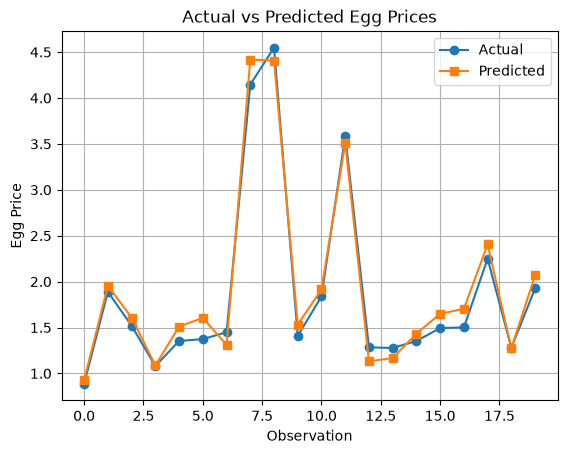

In [71]:
# Compare actual and predicted values
results = pd.DataFrame({
    "Actual Egg Price": y_test,
    "Predicted Egg Price": forest_predictions
})

plt.plot(
    y_test.values[:20],
    marker="o",
    label="Actual"
)

plt.plot(
    forest_predictions[:20],
    marker="s",
    label="Predicted"
)

plt.title("Actual vs Predicted Egg Prices")
plt.xlabel("Observation")
plt.ylabel("Egg Price")

plt.legend()
plt.grid(True)

plt.show()

               Model    MAE   RMSE     R²
0  Linear Regression  0.303  0.451  0.697
1      Decision Tree  0.167  0.231  0.921
2      Random Forest  0.149  0.235  0.918


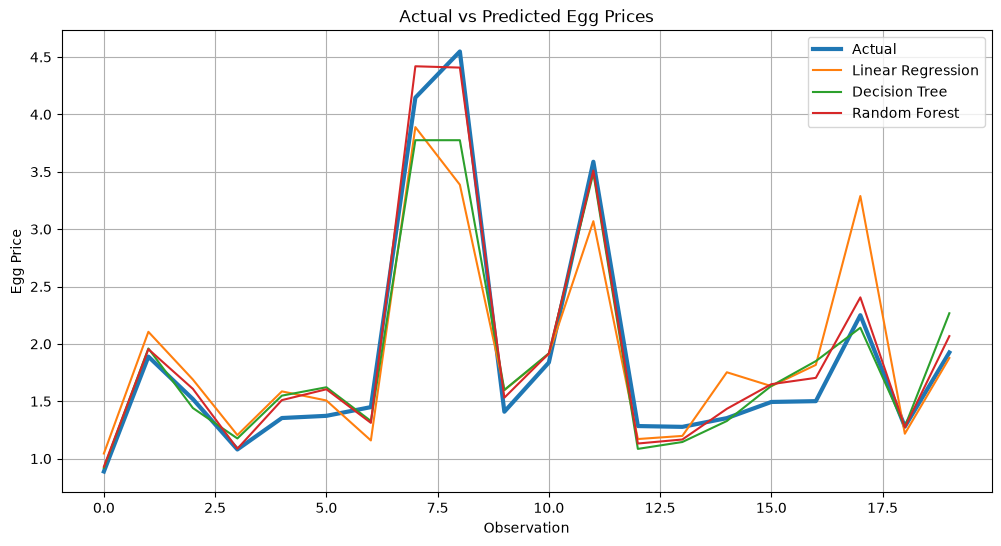

In [72]:
results = pd.DataFrame(columns=[
    "Model",
    "MAE",
    "RMSE",
    "R²"
])

models = [
    ("Linear Regression", linear_predictions),
    ("Decision Tree", tree_predictions),
    ("Random Forest", forest_predictions)
]

for name, prediction in models:

    mae = mean_absolute_error(y_test, prediction)

    rmse = np.sqrt(
        mean_squared_error(y_test, prediction)
    )

    r2 = r2_score(
        y_test,
        prediction
    )

    results.loc[len(results)] = [
        name,
        round(mae,3),
        round(rmse,3),
        round(r2,3)
    ]

print(results)

plt.figure(figsize=(12,6))

plt.plot(y_test.values[:20], label="Actual", linewidth=3)

plt.plot(linear_predictions[:20], label="Linear Regression")

plt.plot(tree_predictions[:20], label="Decision Tree")

plt.plot(forest_predictions[:20], label="Random Forest")

plt.title("Actual vs Predicted Egg Prices")
plt.xlabel("Observation")
plt.ylabel("Egg Price")

plt.legend()

plt.grid(True)

plt.show()

# 13. Hyperparameter Tuning 

In [73]:
# Create the model
forest = RandomForestRegressor(random_state=42)

# Parameters to test
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=forest,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train_prepared, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest RMSE:")
print(-grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}

Best RMSE:
0.3473753419868703


# 14. Model Evaluation
 Purpose:
 Evaluate the performance of each regression model using MAE, RMSE,
 and R². These metrics are used to compare the models and determine which one predicts egg prices most accurately.

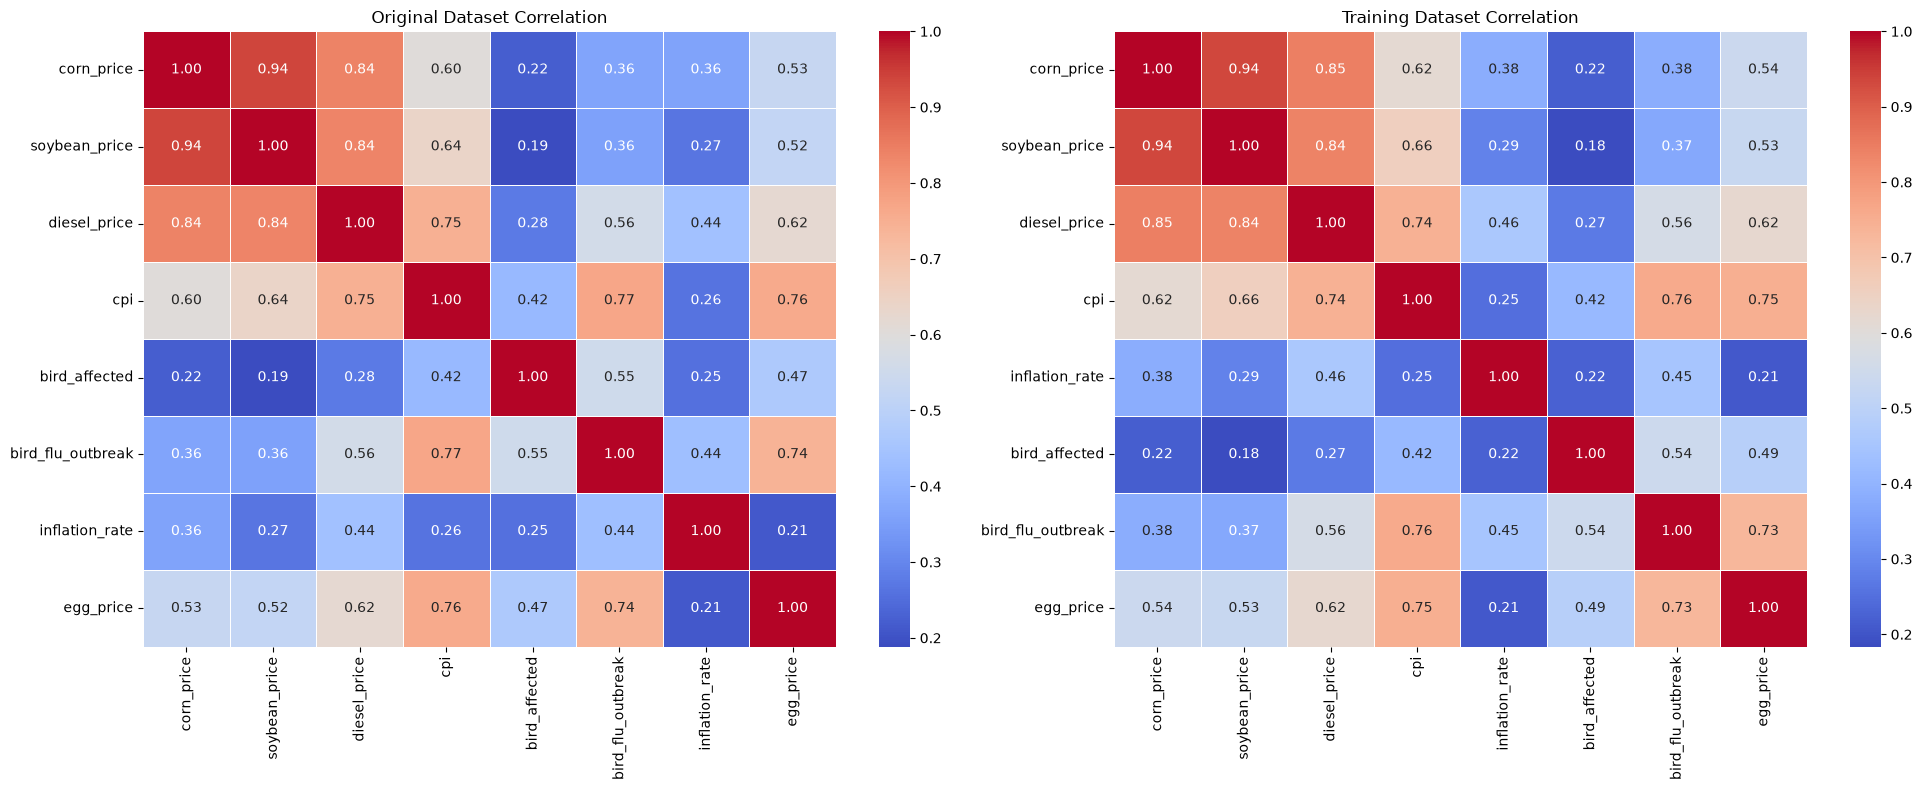

In [74]:
# Original dataset (features + target)
original_data = df[[
    "corn_price",
    "soybean_price",
    "diesel_price",
    "cpi",
    "bird_affected",
    "bird_flu_outbreak",
    "inflation_rate",          # Added
    "egg_price"
]]

original_corr = original_data.corr()

# Training dataset (features + target)
train_data = X_train.copy()
train_data["egg_price"] = y_train

train_corr = train_data.corr()

# Create side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Original dataset
sns.heatmap(
    original_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title("Original Dataset Correlation")

# Training dataset
sns.heatmap(
    train_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title("Training Dataset Correlation")

plt.tight_layout()
plt.show()

In [75]:
tuned_forest_model = grid_search.best_estimator_

tuned_forest_predictions = (
    tuned_forest_model.predict(
        X_test_prepared
    )
)

tuned_forest_mae = mean_absolute_error(
    y_test,
    tuned_forest_predictions
)

tuned_forest_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_forest_predictions
    )
)

tuned_forest_r2 = r2_score(
    y_test,
    tuned_forest_predictions
)

print("Tuned Random Forest Results")
print("---------------------------")
print(f"MAE : {tuned_forest_mae:.3f}")
print(f"RMSE: {tuned_forest_rmse:.3f}")
print(f"R²  : {tuned_forest_r2:.3f}")

Tuned Random Forest Results
---------------------------
MAE : 0.189
RMSE: 0.301
R²  : 0.865


In [76]:
# Evaluate a model
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return [model_name, mae, rmse, r2]

# Create evaluation table
results = pd.DataFrame(columns=["Model", "MAE", "RMSE", "R²"])

results.loc[len(results)] = evaluate_model(
    "Linear Regression",
    y_test,
    linear_predictions
)

results.loc[len(results)] = evaluate_model(
    "Decision Tree",
    y_test,
    tree_predictions
)

results.loc[len(results)] = evaluate_model(
    "Random Forest",
    y_test,
    forest_predictions
)

print(results)

               Model       MAE      RMSE        R²
0  Linear Regression  0.302577  0.451316  0.696916
1      Decision Tree  0.166515  0.230777  0.920752
2      Random Forest  0.148647  0.234988  0.917834


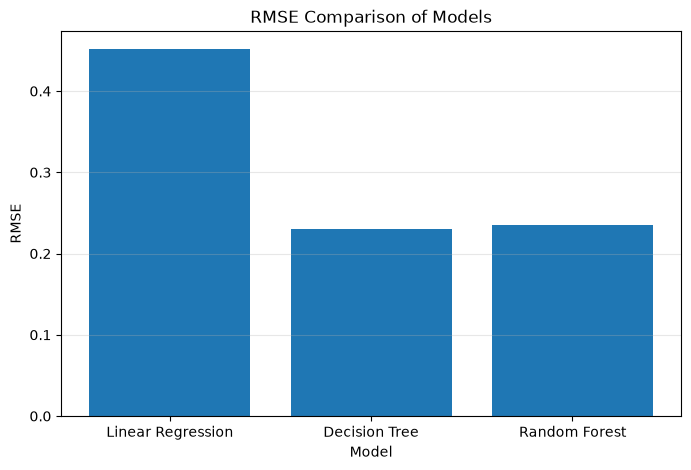

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["RMSE"])

plt.title("RMSE Comparison of Models")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [78]:
# Best tuned Random Forest model
tuned_forest_model = grid_search.best_estimator_

# Make predictions
tuned_forest_predictions = tuned_forest_model.predict(X_test_prepared)

# Calculate evaluation metrics
tuned_forest_mae = mean_absolute_error(
    y_test,
    tuned_forest_predictions
)

tuned_forest_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_forest_predictions
    )
)

tuned_forest_r2 = r2_score(
    y_test,
    tuned_forest_predictions
)

print("Tuned Random Forest Results")
print("---------------------------")
print("MAE :", round(tuned_forest_mae, 3))
print("RMSE:", round(tuned_forest_rmse, 3))
print("R²  :", round(tuned_forest_r2, 3))

Tuned Random Forest Results
---------------------------
MAE : 0.189
RMSE: 0.301
R²  : 0.865


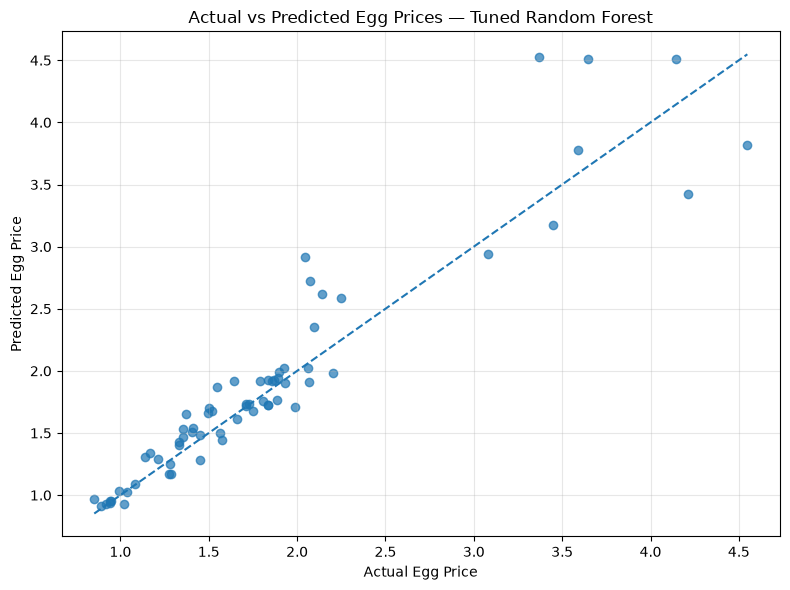

In [79]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    tuned_forest_predictions,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title(
    "Actual vs Predicted Egg Prices — Tuned Random Forest"
)

plt.xlabel("Actual Egg Price")
plt.ylabel("Predicted Egg Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 15. Model Comparison

In [80]:
# Replace the previous results DataFrame with a new one that includes the tuned model
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        linear_mae,
        tree_mae,
        forest_mae,
        tuned_forest_mae
    ],
    "RMSE": [
        linear_rmse,
        tree_rmse,
        forest_rmse,
        tuned_forest_rmse
    ],
    "R²": [
        linear_r2,
        tree_r2,
        forest_r2,
        tuned_forest_r2
    ]
})

print(comparison.round(4))

                 Model     MAE    RMSE      R²
0    Linear Regression  0.3026  0.4513  0.6969
1        Decision Tree  0.1665  0.2308  0.9208
2        Random Forest  0.1486  0.2350  0.9178
3  Tuned Random Forest  0.1890  0.3010  0.8652


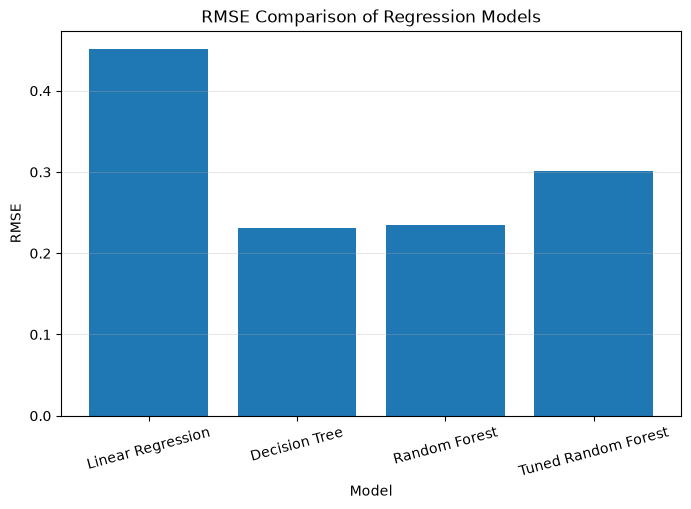

In [81]:
# Visualize the RMSE of all models, including the tuned model
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["RMSE"])

plt.title("RMSE Comparison of Regression Models")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.show()

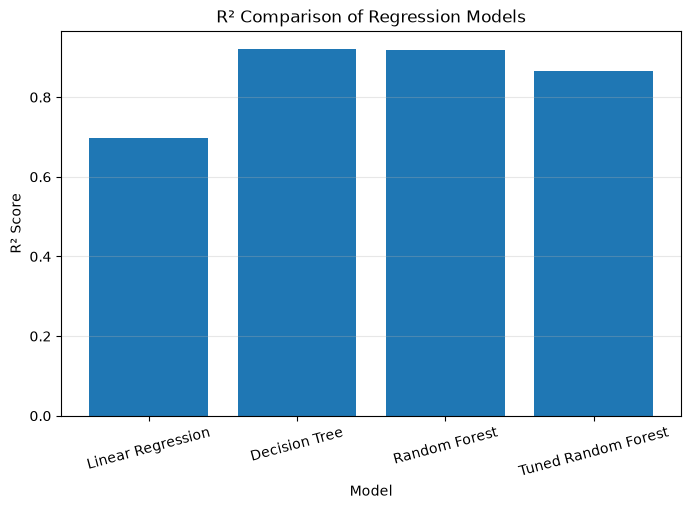

In [82]:
# Visualize the R² of all models, including the tuned model
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["R²"])

plt.title("R² Comparison of Regression Models")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [83]:
best_result = comparison.loc[
    comparison["RMSE"].idxmin()
]

print("Best Model Results")
print(best_result)

model_lookup = {
    "Linear Regression": linear_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model,
    "Tuned Random Forest": tuned_forest_model
}

best_model_name = best_result["Model"]
best_model = model_lookup[best_model_name]

print("\nSelected model:", best_model_name)
print("Model type:", type(best_model))

Best Model Results
Model    Decision Tree
MAE           0.166515
RMSE          0.230777
R²            0.920752
Name: 1, dtype: object

Selected model: Decision Tree
Model type: <class 'sklearn.tree._classes.DecisionTreeRegressor'>


In [84]:
best_result = comparison.loc[comparison["RMSE"].idxmin()]

model_lookup = {
    "Linear Regression": linear_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model,
    "Tuned Random Forest": tuned_forest_model
}

best_model = model_lookup[best_result["Model"]]

# 16. Feature Importance Analysis

Feature importance was used to identify which input variables contributed
the most to the final tree-based model's egg price predictions. Higher
importance values indicate that a feature was more useful to the model.
Feature importance does not prove a cause-and-effect relationship.

In [85]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

feature_importance["Importance (%)"] = (
    feature_importance["Importance"] * 100
).round(2)

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print(feature_importance)

             Feature  Importance  Importance (%)
0      bird_affected    0.540904           54.09
1      soybean_price    0.153398           15.34
2       diesel_price    0.130785           13.08
3         corn_price    0.071489            7.15
4                cpi    0.062423            6.24
5     inflation_rate    0.041002            4.10
6  bird_flu_outbreak    0.000000            0.00


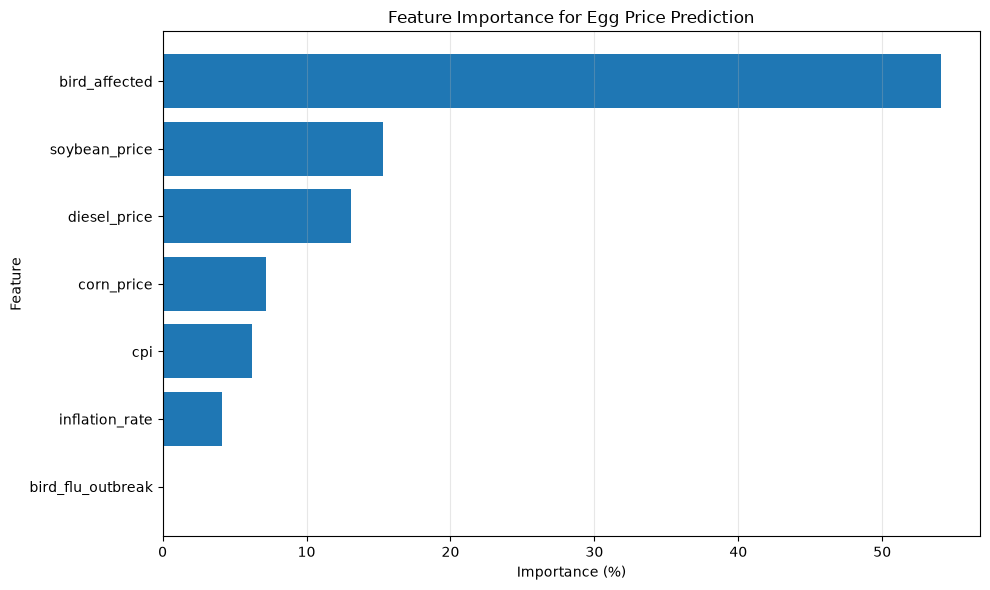

In [86]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance (%)"]
)

plt.title("Feature Importance for Egg Price Prediction")
plt.xlabel("Importance (%)")
plt.ylabel("Feature")

plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [87]:
print("Feature Importance Ranking")
print("-" * 45)

for _, row in feature_importance.iterrows():
    print(
        f"{row['Feature']:<30}"
        f"{row['Importance (%)']:>8.2f}%"
    )

Feature Importance Ranking
---------------------------------------------
bird_affected                    54.09%
soybean_price                    15.34%
diesel_price                     13.08%
corn_price                        7.15%
cpi                               6.24%
inflation_rate                    4.10%
bird_flu_outbreak                 0.00%


### Interpretation

The feature importance analysis identified the variables that contributed the most to predicting egg prices. Features with higher importance percentages had a greater influence on the model's predictions.

The results indicate which economic and agricultural factors were most useful for forecasting egg prices in this study. Although these variables were important to the model, feature importance should not be interpreted as proof that a variable directly causes changes in egg prices. Instead, it shows how useful each feature was for making accurate predictions..

# 17. Time Series Validation

The TimeSeriesSplit results were similar to the original train/test split, indicating that the model generalizes reasonably well to future observations.

In [88]:
time_data = (
    df.sort_values("date")
      .reset_index(drop=True)
)

X_time = time_data[X.columns]
y_time = time_data["egg_price"]

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_index, validation_index) in enumerate(
    tscv.split(X_time),
    start=1
):
    train_start = time_data.loc[
        train_index[0],
        "date"
    ]

    train_end = time_data.loc[
        train_index[-1],
        "date"
    ]

    validation_start = time_data.loc[
        validation_index[0],
        "date"
    ]

    validation_end = time_data.loc[
        validation_index[-1],
        "date"
    ]

    print(f"Fold {fold}")
    print(
        f"Train: {train_start} to {train_end}"
    )
    print(
        f"Validation: {validation_start} "
        f"to {validation_end}"
    )
    print("-" * 55)

Fold 1
Train: 1999-01-01 00:00:00 to 2003-07-01 00:00:00
Validation: 2003-08-01 00:00:00 to 2008-02-01 00:00:00
-------------------------------------------------------
Fold 2
Train: 1999-01-01 00:00:00 to 2008-02-01 00:00:00
Validation: 2008-03-01 00:00:00 to 2012-09-01 00:00:00
-------------------------------------------------------
Fold 3
Train: 1999-01-01 00:00:00 to 2012-09-01 00:00:00
Validation: 2012-10-01 00:00:00 to 2017-04-01 00:00:00
-------------------------------------------------------
Fold 4
Train: 1999-01-01 00:00:00 to 2017-04-01 00:00:00
Validation: 2017-05-01 00:00:00 to 2021-11-01 00:00:00
-------------------------------------------------------
Fold 5
Train: 1999-01-01 00:00:00 to 2021-11-01 00:00:00
Validation: 2021-12-01 00:00:00 to 2026-06-01 00:00:00
-------------------------------------------------------


In [89]:
time_series_results = []

for fold, (train_index, validation_index) in enumerate(
    tscv.split(X_time),
    start=1
):
    X_fold_train = X_time.iloc[
        train_index
    ]

    X_fold_validation = X_time.iloc[
        validation_index
    ]

    y_fold_train = y_time.iloc[
        train_index
    ]

    y_fold_validation = y_time.iloc[
        validation_index
    ]

    fold_preprocessing = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ])

    X_fold_train_prepared = (
        fold_preprocessing.fit_transform(
            X_fold_train
        )
    )

    X_fold_validation_prepared = (
        fold_preprocessing.transform(
            X_fold_validation
        )
    )

    fold_model = RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    )

    fold_model.fit(
        X_fold_train_prepared,
        y_fold_train
    )

    fold_predictions = fold_model.predict(
        X_fold_validation_prepared
    )

    time_series_results.append({
        "Fold": fold,
        "MAE": mean_absolute_error(
            y_fold_validation,
            fold_predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_fold_validation,
                fold_predictions
            )
        ),
        "R²": r2_score(
            y_fold_validation,
            fold_predictions
        )
    })

In [90]:
time_series_results = pd.DataFrame(
    time_series_results
)

print("Time-Series Validation Results")
print(time_series_results.round(4))

print("\nAverage Time-Series Performance")
print("--------------------------------")
print(
    f"Average MAE: "
    f"{time_series_results['MAE'].mean():.4f}"
)
print(
    f"Average RMSE: "
    f"{time_series_results['RMSE'].mean():.4f}"
)
print(
    f"Average R²: "
    f"{time_series_results['R²'].mean():.4f}"
)

Time-Series Validation Results
   Fold     MAE    RMSE      R²
0     1  0.2876  0.3898 -1.2310
1     2  0.2260  0.2608 -1.7602
2     3  0.3427  0.4595 -0.4353
3     4  0.2060  0.2550 -0.7257
4     5  1.3321  1.6544 -1.8179

Average Time-Series Performance
--------------------------------
Average MAE: 0.4789
Average RMSE: 0.6039
Average R²: -1.1940


In [91]:
# Create five chronological folds
tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_index, validation_index) in enumerate(
    tscv.split(X_time),
    start=1
):
    train_start = time_data.loc[train_index[0], "date"]
    train_end = time_data.loc[train_index[-1], "date"]

    validation_start = time_data.loc[validation_index[0], "date"]
    validation_end = time_data.loc[validation_index[-1], "date"]

print(f"\nFold {fold}")
print(f"Training Period:   {train_start} → {train_end}")
print(f"Validation Period: {validation_start} → {validation_end}")
print("-" * 60)


Fold 5
Training Period:   1999-01-01 00:00:00 → 2021-11-01 00:00:00
Validation Period: 2021-12-01 00:00:00 → 2026-06-01 00:00:00
------------------------------------------------------------


In [92]:
time_series_results = []

for fold, (train_index, validation_index) in enumerate(
    tscv.split(X_time),
    start=1
):
    # Chronological training and validation sets
    X_fold_train = X_time.iloc[train_index]
    X_fold_validation = X_time.iloc[validation_index]

    y_fold_train = y_time.iloc[train_index]
    y_fold_validation = y_time.iloc[validation_index]

    # Fit preprocessing only on this fold's training data
    X_fold_train_prepared = preprocessing.fit_transform(X_fold_train)

    # Apply learned preprocessing to later validation data
    X_fold_validation_prepared = preprocessing.transform(
        X_fold_validation
    )

    # Train Random Forest
    time_model = RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    )

    time_model.fit(
        X_fold_train_prepared,
        y_fold_train
    )

    # Predict later observations
    fold_predictions = time_model.predict(
        X_fold_validation_prepared
    )

    # Calculate metrics
    fold_mae = mean_absolute_error(
        y_fold_validation,
        fold_predictions
    )

    fold_rmse = np.sqrt(
        mean_squared_error(
            y_fold_validation,
            fold_predictions
        )
    )

    fold_r2 = r2_score(
        y_fold_validation,
        fold_predictions
    )

    time_series_results.append({
        "Fold": fold,
        "MAE": fold_mae,
        "RMSE": fold_rmse,
        "R²": fold_r2
    })

In [93]:
time_series_results = pd.DataFrame(time_series_results)

print("Time Series Validation Results")
print(time_series_results.round(4))

print("\nAverage Time Series Performance")
print("--------------------------------")
print(f"Average MAE:  {time_series_results['MAE'].mean():.4f}")
print(f"Average RMSE: {time_series_results['RMSE'].mean():.4f}")
print(f"Average R²:   {time_series_results['R²'].mean():.4f}")

Time Series Validation Results
   Fold     MAE    RMSE      R²
0     1  0.2876  0.3898 -1.2310
1     2  0.2260  0.2608 -1.7602
2     3  0.3427  0.4595 -0.4353
3     4  0.2060  0.2550 -0.7257
4     5  1.3321  1.6544 -1.8179

Average Time Series Performance
--------------------------------
Average MAE:  0.4789
Average RMSE: 0.6039
Average R²:   -1.1940


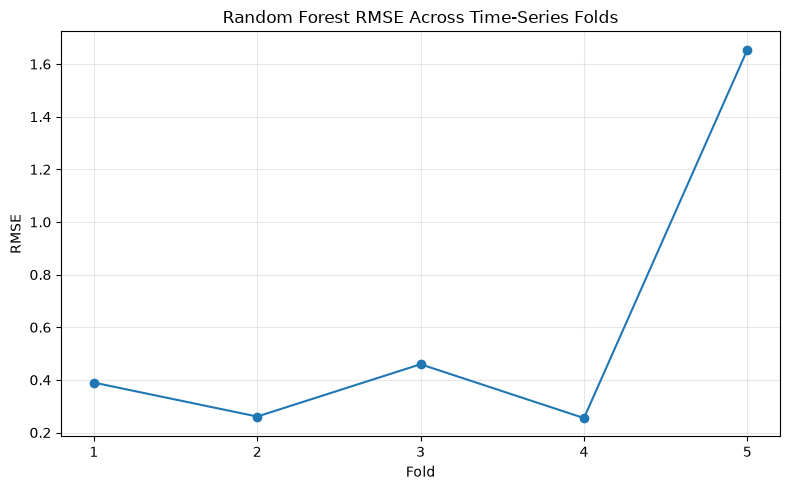

In [94]:

plt.figure(figsize=(8, 5))

plt.plot(
    time_series_results["Fold"],
    time_series_results["RMSE"],
    marker="o"
)

plt.title("Random Forest RMSE Across Time-Series Folds")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.xticks(time_series_results["Fold"])
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Interpretation

TimeSeriesSplit evaluated the model using earlier months for training and later months for validation. The average MAE, RMSE, and R² provide a more realistic estimate of how the model may perform when predicting future egg prices.

These results may be weaker than the results from the random train/test split because chronological validation is more difficult and does not allow the model to learn from future observations. Large differences between folds may also indicate that the relationship between the predictors and egg prices changed over time.

# 18. Conclusion 

# 18. Conclusion and Future Work

The objective of this project was to develop a machine learning model capable of predicting the monthly average retail price of one dozen Grade A large eggs in the United States. Historical data for egg prices, corn prices, soybean prices, diesel prices, the Consumer Price Index, inflation, and bird flu activity were combined into one dataset.

Exploratory Data Analysis was used to examine trends, distributions, outliers, and relationships between variables. Feature engineering was also performed by creating a binary bird flu outbreak indicator and calculating the inflation rate from CPI data.

Three regression models were trained and evaluated: Linear Regression, Decision Tree Regressor, and Random Forest Regressor. A tuned Random Forest model was also created using GridSearchCV. The models were compared using Mean Absolute Error, Root Mean Squared Error, and R².

The best-performing model was selected based primarily on the lowest RMSE and highest R². Feature importance analysis was used to identify which economic and agricultural variables contributed most to the model's predictions.

TimeSeriesSplit was also used to evaluate the model chronologically. This provided a more realistic estimate of future forecasting performance because earlier observations were used for training and later observations were used for validation.

Although the model produced useful predictions, several limitations remain. Bird flu data covered a shorter period than the economic datasets, and other factors such as weather, labor costs, consumer demand, transportation costs, government policies, and supply-chain disruptions were not included.

Future improvements could include collecting additional bird flu data, adding lagged egg-price features and moving averages, testing advanced models such as XGBoost or LightGBM, and exploring forecasting methods such as ARIMA, Prophet, or LSTM neural networks. The final model could also be deployed as a web application so users can enter new values and receive egg-price predictions.

Overall, this project demonstrates how machine learning can be used to analyze historical economic and agricultural data and estimate future egg prices. The project includes a complete workflow from data preparation and exploratory analysis through model training, evaluation, interpretation, time-series validation, and prediction.


# 19. Save the Final Model

In [95]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(
    best_model,
    "models/egg_price_model.pkl"
)

joblib.dump(
    preprocessing,
    "models/egg_price_preprocessing.pkl"
)

print("Model and preprocessing saved.")

Model and preprocessing saved.


This section saves the final trained machine learning model and the preprocessing pipeline. Saving both allows the model to be reused later without retraining. The saved files can be loaded by a Python program, web application, or desktop application to make new egg price predictions.